<a href="https://colab.research.google.com/github/pranatixsharma/Delhi-AQI-source-allocation/blob/main/FINAL_Delhi_AQI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement

- Q1 — What are the dominant pollution profiles across Delhi NCR monitoring stations? Are all stations equally polluted or are some structurally worse?
- Q2 — How Much Can Policy Help? What is the quantifiable impact of intervention on air quality?
- Q3 — Weather or Humans? What proportion of AQI variation is driven by meteorology (wind, temperature, humidity) vs human activity (vehicles, industry)? Can we predict AQI using weather data alone?







# Data collection
import dataset



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df= pd.read_csv("/content/drive/MyDrive/delhi_ncr_aqi_dataset.csv")
df.head()

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.60,47.70,5.19,12.30,9.40,100,3.60,1.20,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.90,39.30,4.32,15.80,20.60,50,5.90,1.40,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.10,36.30,7.13,14.30,12.40,56,4.50,1.10,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.00,30.30,4.90,13.20,14.40,48,5.80,1.40,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.40,41.50,7.56,15.40,6.80,100,2.80,0.40,500,Severe


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.float_format', '{:.2f}'.format)
print("✓ Imports done")

✓ Imports done


#Data understanding/ EDA

In [ ]:
# Basic inspection
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  object 
 1   date          201664 non-null  object 
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  object 
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  object 
 9   city          201664 non-null  object 
 10  station       201664 non-null  object 
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  flo

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

Shape: (201664, 25)

Columns:
 Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')


In [ ]:
df.describe()

,year,month,day,hour,is_weekend,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
count,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00,201664.00
mean,2022.50,6.52,15.73,14.75,0.29,28.60,77.21,183.42,348.57,69.76,16.03,3.03,27.19,26.90,61.04,10.53,5.01,265.83
std,1.71,3.45,8.80,6.38,0.45,0.11,0.13,193.14,370.02,75.97,17.20,3.28,13.57,8.98,24.74,6.05,3.69,171.51
min,2020.00,1.00,1.00,6.00,0.00,28.37,77.03,15.00,24.00,8.00,4.00,0.30,12.00,6.00,20.00,2.10,0.20,25.00
25%,2021.00,4.00,8.00,10.50,0.00,28.53,77.07,55.30,104.10,19.90,4.50,0.87,18.00,19.90,39.00,5.90,1.90,103.00
50%,2022.50,7.00,16.00,15.00,0.00,28.62,77.20,99.50,189.80,38.30,8.70,1.69,23.30,27.60,58.00,9.20,4.40,232.00
75%,2024.00,10.00,23.00,19.25,1.00,28.67,77.32,254.70,481.20,94.00,20.90,4.12,31.80,33.50,83.00,14.20,7.10,464.00
max,2025.00,12.00,31.00,23.00,1.00,28.78,77.50,900.00,1979.70,593.50,121.60,22.67,84.00,44.80,100.00,31.50,15.00,500.00


BoxPlot with statistics printed

Season: monsoon
  - 25th Percentile (Q1): 54.0
  - Median: 82.0
  - 75th Percentile (Q3): 105.0
  - IQR: 51.0
  - Minimum Value (Whisker): 25.0
  - Maximum Value (Whisker): 263.0
----------------------------------------
Season: post_monsoon
  - 25th Percentile (Q1): 345.0
  - Median: 426.0
  - 75th Percentile (Q3): 500.0
  - IQR: 155.0
  - Minimum Value (Whisker): 263.0
  - Maximum Value (Whisker): 500.0
----------------------------------------
Season: summer
  - 25th Percentile (Q1): 152.0
  - Median: 198.0
  - 75th Percentile (Q3): 255.0
  - IQR: 103.0
  - Minimum Value (Whisker): 73.0
  - Maximum Value (Whisker): 376.0
----------------------------------------
Season: winter
  - 25th Percentile (Q1): 407.0
  - Median: 500.0
  - 75th Percentile (Q3): 500.0
  - IQR: 93.0
  - Minimum Value (Whisker): 304.0
  - Maximum Value (Whisker): 500.0
----------------------------------------


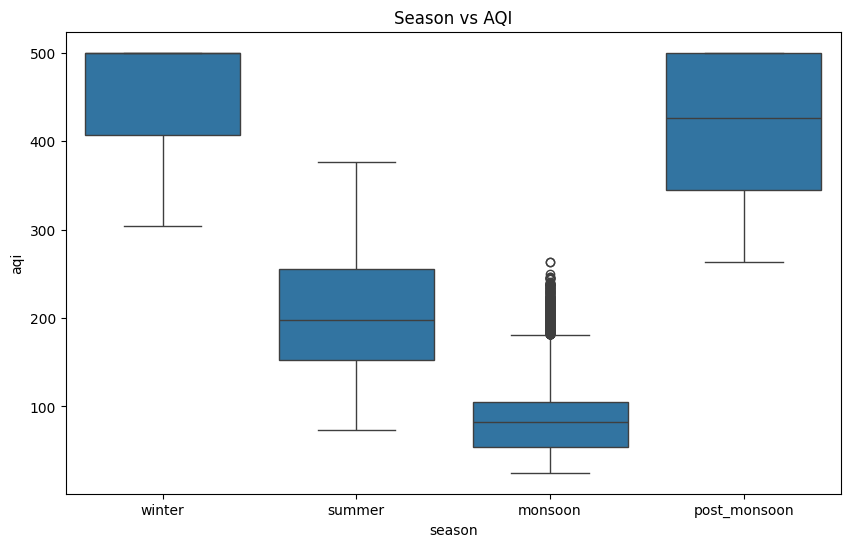

In [ ]:
# Extracting specific statistics for each season

plt.figure(figsize=(10,6))
sns.boxplot(x='season', y='aqi', data=df)

# Get the statistical values (e.g., quartiles, median, whiskers)
stats = df.groupby('season')['aqi'].describe()
for season in stats.index:
    print(f"Season: {season}")
    print(f"  - 25th Percentile (Q1): {stats.loc[season, '25%']}")
    print(f"  - Median: {stats.loc[season, '50%']}")
    print(f"  - 75th Percentile (Q3): {stats.loc[season, '75%']}")
    print(f"  - IQR: {stats.loc[season, '75%'] - stats.loc[season, '25%']}")
    print(f"  - Minimum Value (Whisker): {stats.loc[season, 'min']}")
    print(f"  - Maximum Value (Whisker): {stats.loc[season, 'max']}")
    #print(f"  - Outliers: {df[(df['season'] == season) & ((df['aqi'] < stats.loc[season, '25%'] - 1.5 * (stats.loc[season, '75%'] - stats.loc[season, '25%'])) | (df['aqi'] > stats.loc[season, '75%'] + 1.5 * (stats.loc[season, '75%'] - stats.loc[season, '25%'])))]['aqi'].values}")
    print('-' * 40)

plt.title("Season vs AQI")
plt.show()

Define Target & Remove Unnecessary Columns


In [ ]:
# Drop unnecessary columns

df_model = df.drop(columns=[
    "datetime",
    "date",
    "city",
    "station",
    "latitude",
    "longitude"
])

print("New Shape:", df_model.shape)
print("\nRemaining Columns:\n", df_model.columns)

New Shape: (201664, 19)

Remaining Columns:
 Index(['year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')


In [ ]:

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (201664, 25)

Columns: ['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi', 'aqi_category']

Dtypes:
 datetime         object
date             object
year              int64
month             int64
day               int64
hour              int64
day_of_week      object
is_weekend        int64
season           object
city             object
station          object
latitude        float64
longitude       float64
pm25            float64
pm10            float64
no2             float64
so2             float64
co              float64
o3              float64
temperature     float64
humidity          int64
wind_speed      float64
visibility      float64
aqi               int64
aqi_category     object
dtype: object

First 5 rows:


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.60,47.70,5.19,12.30,9.40,100,3.60,1.20,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.90,39.30,4.32,15.80,20.60,50,5.90,1.40,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.10,36.30,7.13,14.30,12.40,56,4.50,1.10,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.00,30.30,4.90,13.20,14.40,48,5.80,1.40,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.40,41.50,7.56,15.40,6.80,100,2.80,0.40,500,Severe


Checking for null values


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).sort_values('Missing %', ascending=False)

,Missing Count,Missing %
datetime,0,0.00
date,0,0.00
year,0,0.00
month,0,0.00
day,0,0.00
hour,0,0.00
day_of_week,0,0.00
is_weekend,0,0.00
season,0,0.00
city,0,0.00


Sanity check for hidden nulls/zeros

In [ ]:
# Check for zeros in pollutant columns (zero pollution is physically suspicious)
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
weather = ['temperature', 'humidity', 'wind_speed', 'visibility']

print("=== Zero value counts (pollutants) ===")
for col in pollutants:
    zeros = (df[col] == 0).sum()
    print(f"{col}: {zeros} zeros ({zeros/len(df)*100:.2f}%)")

print("\n=== Negative values ===")
for col in pollutants + weather:
    negs = (df[col] < 0).sum()
    print(f"{col}: {negs} negatives")


=== Zero value counts (pollutants) ===
pm25: 0 zeros (0.00%)
pm10: 0 zeros (0.00%)
no2: 0 zeros (0.00%)
so2: 0 zeros (0.00%)
co: 0 zeros (0.00%)
o3: 0 zeros (0.00%)

=== Negative values ===
pm25: 0 negatives
pm10: 0 negatives
no2: 0 negatives
so2: 0 negatives
co: 0 negatives
o3: 0 negatives
temperature: 0 negatives
humidity: 0 negatives
wind_speed: 0 negatives
visibility: 0 negatives


AQI range & category distribution

In [ ]:
print("AQI stats:\n", df['aqi'].describe())
print("\nAQI Category distribution:\n", df['aqi_category'].value_counts())

AQI stats:
 count   201664.00
mean       265.83
std        171.51
min         25.00
25%        103.00
50%        232.00
75%        464.00
max        500.00
Name: aqi, dtype: float64

AQI Category distribution:
 aqi_category
Severe          60102
Moderate        45397
Satisfactory    32860
Very Poor       29674
Poor            18843
Good            14788
Name: count, dtype: int64


Station & city inventory

In [ ]:
print("Cities:", df['city'].unique())
print("\nStation count:", df['station'].nunique())
print("\nStations per city:\n", df.groupby('city')['station'].nunique())

Cities: ['Delhi' 'Noida' 'Gurugram' 'Faridabad' 'Ghaziabad']

Station count: 23

Stations per city:
 city
Delhi        14
Faridabad     2
Ghaziabad     2
Gurugram      2
Noida         3
Name: station, dtype: int64


 Temporal coverage

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
print("Date range:", df['datetime'].min(), "→", df['datetime'].max())
print("\nRecords per year:\n", df['year'].value_counts().sort_index())
print("\nExpected hourly records per station:", 5*365*24)
print("Avg records per station:", len(df)/df['station'].nunique())

Date range: 2020-01-01 06:00:00 → 2025-12-31 23:00:00

Records per year:
 year
2020    33672
2021    33580
2022    33580
2023    33580
2024    33672
2025    33580
Name: count, dtype: int64

Expected hourly records per station: 43800
Avg records per station: 8768.0


AQI Distribution


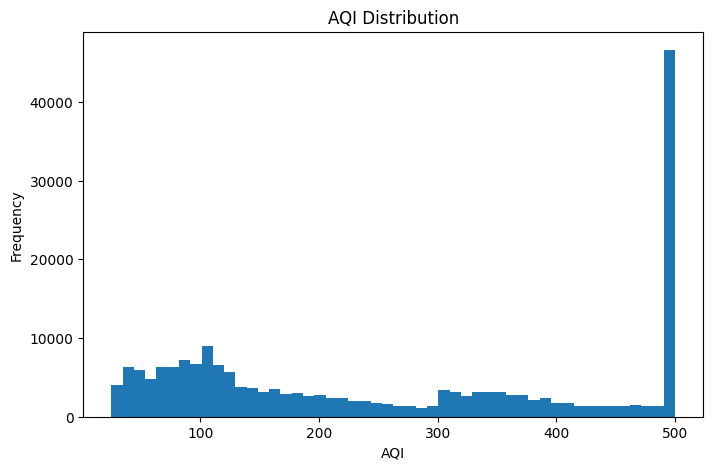

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['aqi'], bins=50)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#Checking the AQI 500 ceiling
print("Records with AQI = 500:", (df['aqi'] == 500).sum())
print("That's:", (df['aqi'] == 500).sum() / len(df) * 100, "%")

# Which cities hit the ceiling most?
df[df['aqi']==500]['city'].value_counts()

Records with AQI = 500: 45355
That's: 22.49038003808315 %


,count
city,
Delhi,28363
Noida,5208
Ghaziabad,4421
Faridabad,3799
Gurugram,3564


#Correlation Heatmap

Pollutant relationships (correlations, weather interactions)

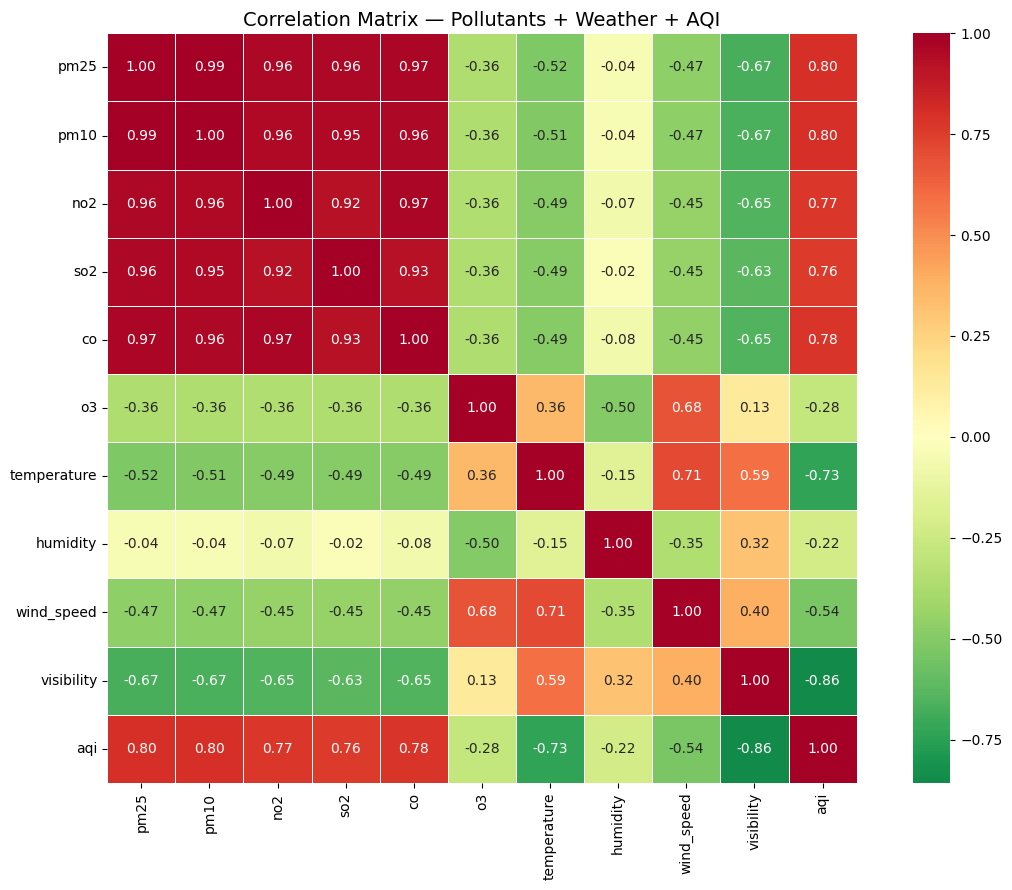

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
            'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi']

corr = df[features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Pollutants + Weather + AQI', fontsize=14)
plt.tight_layout()
plt.show()

#Pairwise Scatter Plots

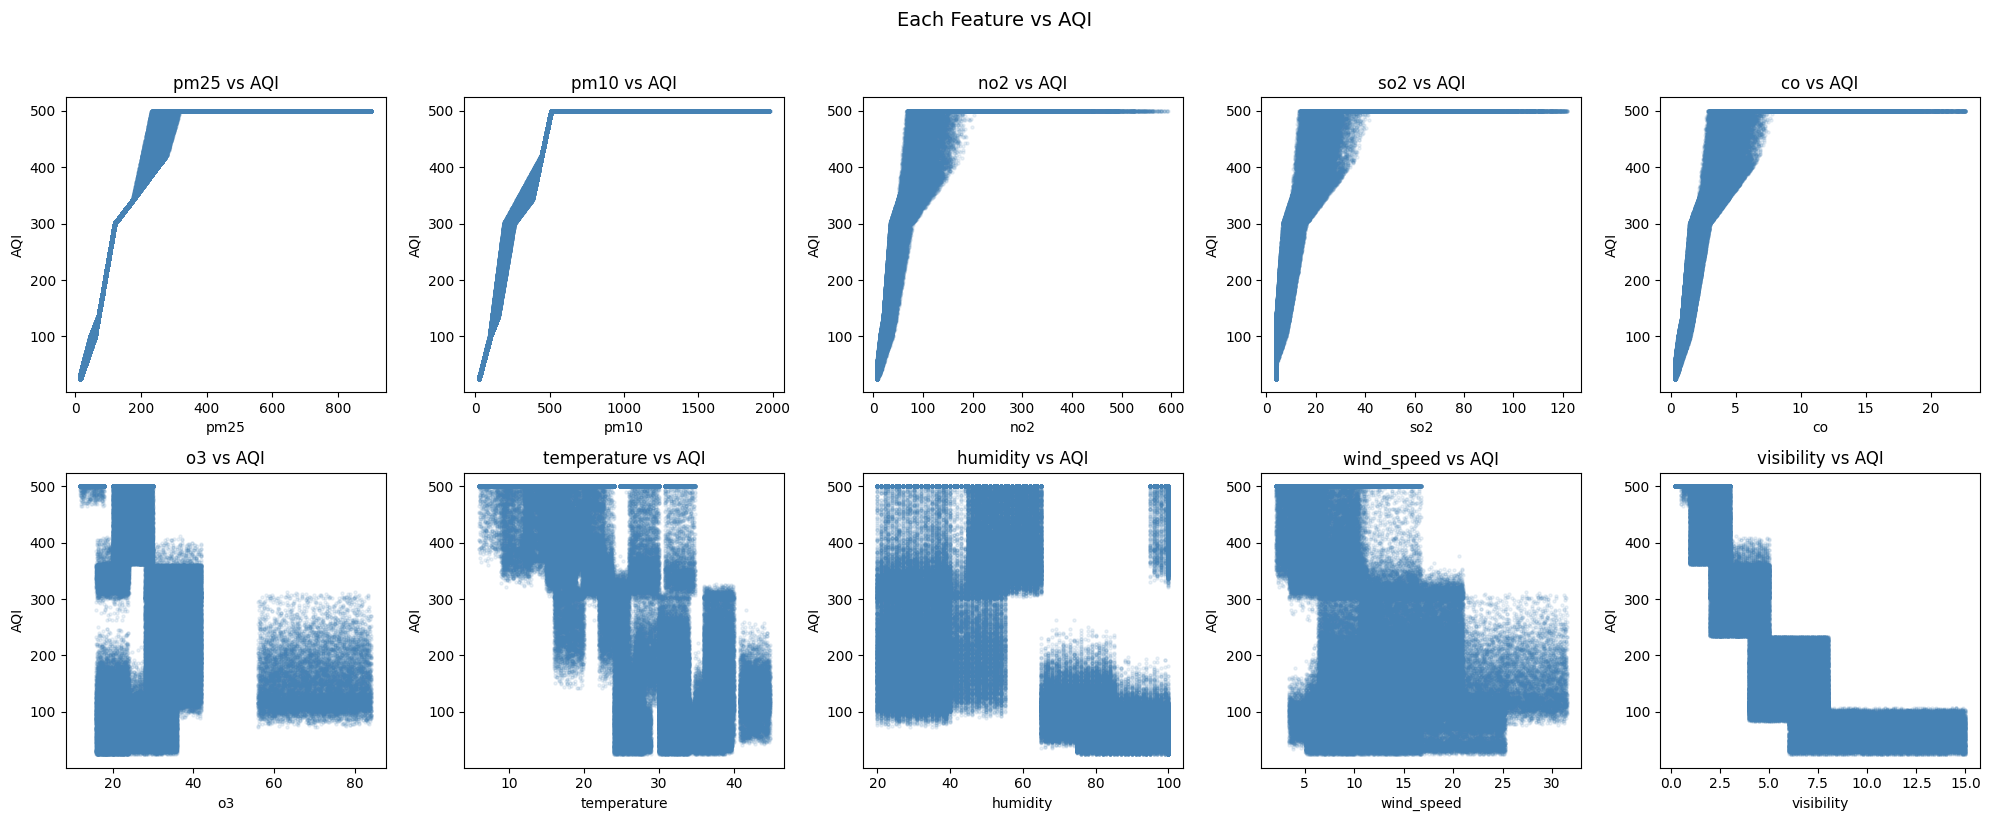

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features[:-1]):  # exclude aqi itself
    axes[i].scatter(df[col], df['aqi'], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('AQI')
    axes[i].set_title(f'{col} vs AQI')

plt.suptitle('Each Feature vs AQI', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#Meteorological Factors vs AQI and Pollutant Levels

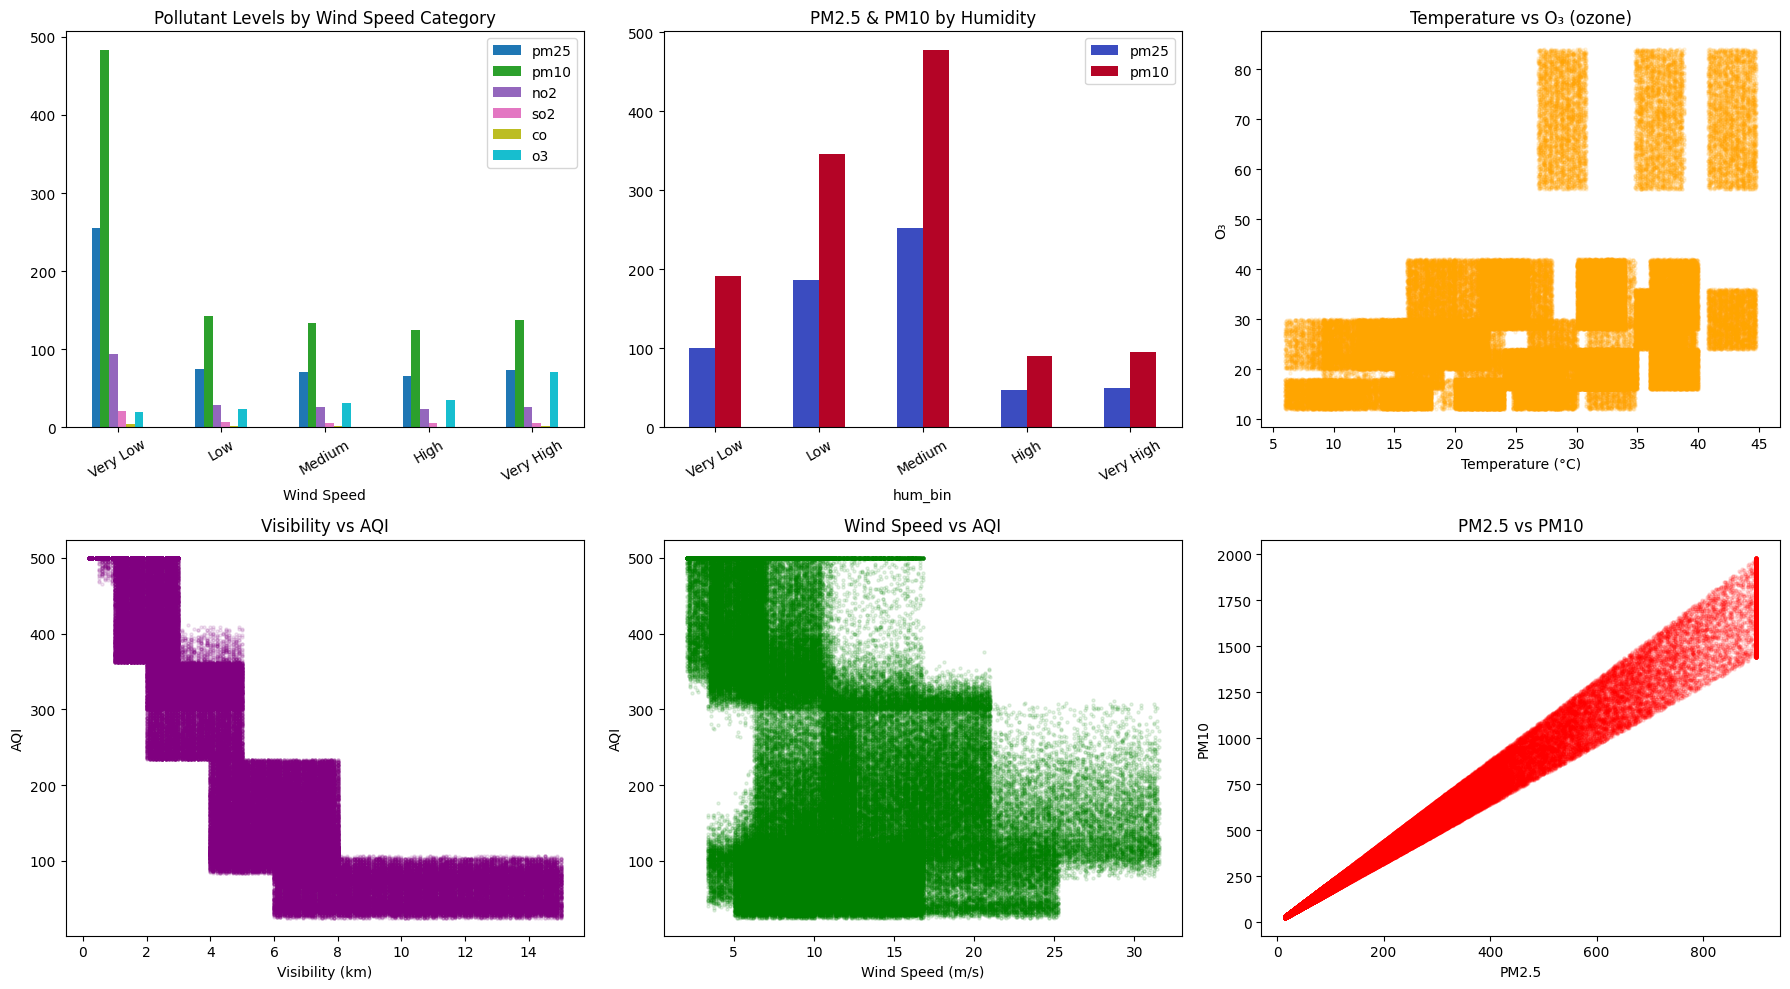

In [ ]:
# Does wind speed suppress pollution?
# Does humidity amplify PM2.5?

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

weather_vars = ['temperature', 'humidity', 'wind_speed', 'visibility']
poll_vars = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

# Bin wind speed into categories
df['wind_bin'] = pd.cut(df['wind_speed'], bins=5,
                         labels=['Very Low','Low','Medium','High','Very High'])

# Pollutant medians by wind category
wind_poll = df.groupby('wind_bin', observed=True)[poll_vars].median()
wind_poll.plot(kind='bar', ax=axes[0,0], colormap='tab10')
axes[0,0].set_title('Pollutant Levels by Wind Speed Category')
axes[0,0].set_xlabel('Wind Speed')
axes[0,0].tick_params(axis='x', rotation=30)

# Humidity bins
df['hum_bin'] = pd.cut(df['humidity'], bins=5,
                        labels=['Very Low','Low','Medium','High','Very High'])
hum_poll = df.groupby('hum_bin', observed=True)[['pm25','pm10']].median()
hum_poll.plot(kind='bar', ax=axes[0,1], colormap='coolwarm')
axes[0,1].set_title('PM2.5 & PM10 by Humidity')
axes[0,1].tick_params(axis='x', rotation=30)

# Temperature vs O3 (ozone formation is heat-driven)
axes[0,2].scatter(df['temperature'], df['o3'], alpha=0.1, s=5, color='orange')
axes[0,2].set_title('Temperature vs O₃ (ozone)')
axes[0,2].set_xlabel('Temperature (°C)')
axes[0,2].set_ylabel('O₃')

# Visibility vs AQI
axes[1,0].scatter(df['visibility'], df['aqi'], alpha=0.1, s=5, color='purple')
axes[1,0].set_title('Visibility vs AQI')
axes[1,0].set_xlabel('Visibility (km)')
axes[1,0].set_ylabel('AQI')

# Wind speed vs AQI
axes[1,1].scatter(df['wind_speed'], df['aqi'], alpha=0.1, s=5, color='green')
axes[1,1].set_title('Wind Speed vs AQI')
axes[1,1].set_xlabel('Wind Speed (m/s)')
axes[1,1].set_ylabel('AQI')

# PM2.5 vs PM10 relationship
axes[1,2].scatter(df['pm25'], df['pm10'], alpha=0.1, s=5, color='red')
axes[1,2].set_title('PM2.5 vs PM10')
axes[1,2].set_xlabel('PM2.5')
axes[1,2].set_ylabel('PM10')

plt.tight_layout()
plt.show()

#City vs AQI

            pm25   pm10   no2  so2   co    o3    aqi
city                                                
Ghaziabad 105.00 199.60 40.20 9.90 1.80 23.10 250.00
Delhi     101.30 193.10 39.00 9.10 1.70 23.20 238.00
Faridabad  97.60 185.40 37.50 7.80 1.60 23.40 225.50
Gurugram   94.10 179.00 36.00 7.70 1.60 23.50 214.00
Noida      92.80 177.50 35.70 7.50 1.60 23.60 209.00


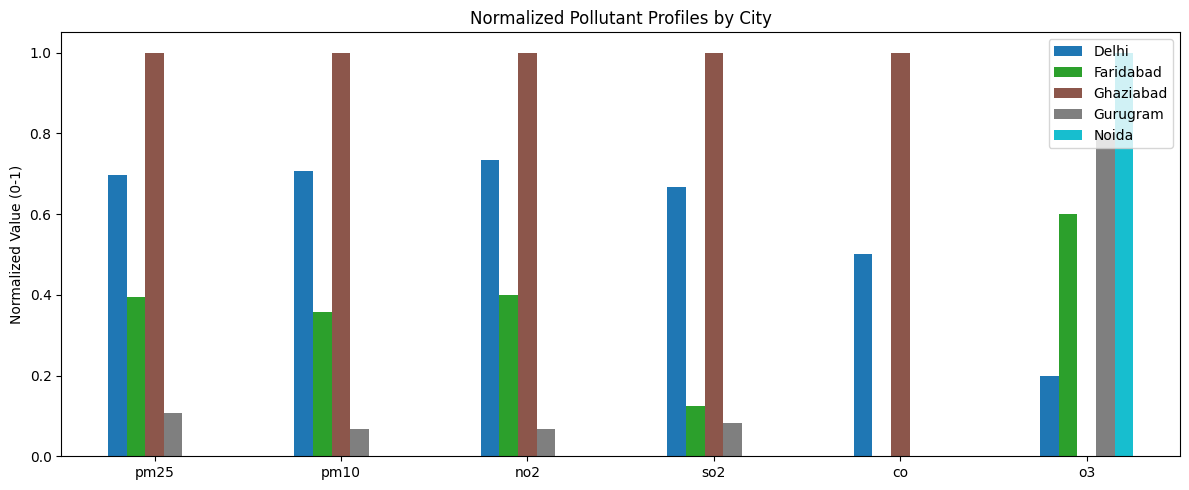

In [ ]:
#Normalized Pollutant profiles by City
city_poll = df.groupby('city')[poll_vars + ['aqi']].median().round(1)
print(city_poll.sort_values('aqi', ascending=False))

# Normalized radar-style comparison
city_poll_norm = (city_poll - city_poll.min()) / (city_poll.max() - city_poll.min())
city_poll_norm.drop(columns='aqi').T.plot(kind='bar', figsize=(12,5), colormap='tab10')
plt.title('Normalized Pollutant Profiles by City')
plt.ylabel('Normalized Value (0-1)')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

#Temporal EDA (seasonal trends, COVID dip, Diwali spikes)



Annual trend: is Delhi NCR getting better or worse?


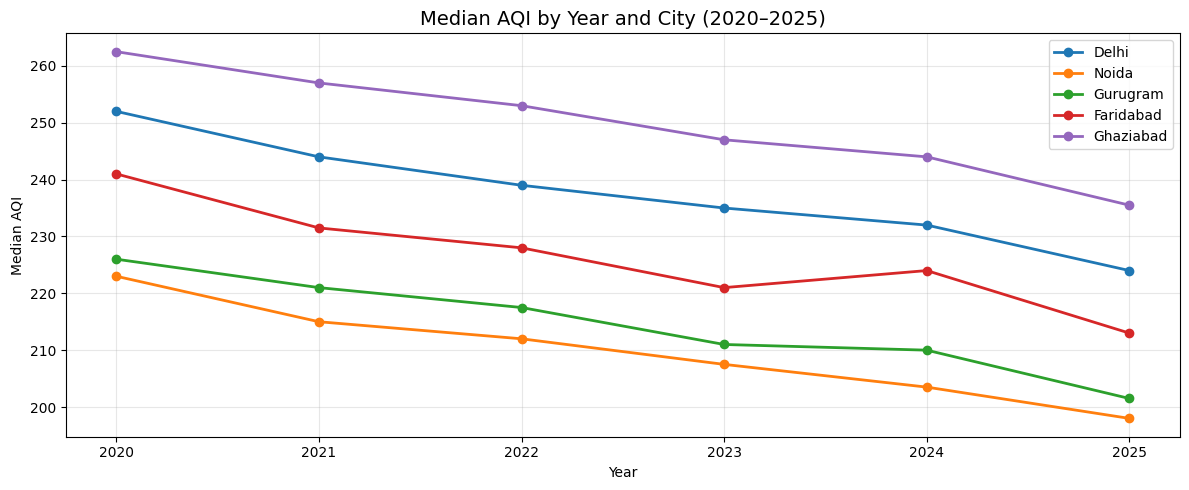

city  Delhi  Faridabad  Ghaziabad  Gurugram  Noida
year                                              
2020 252.00     241.00     262.50    226.00 223.00
2021 244.00     231.50     257.00    221.00 215.00
2022 239.00     228.00     253.00    217.50 212.00
2023 235.00     221.00     247.00    211.00 207.50
2024 232.00     224.00     244.00    210.00 203.50
2025 224.00     213.00     235.50    201.50 198.00


In [ ]:
yearly = df.groupby(['year', 'city'])['aqi'].median().reset_index()

plt.figure(figsize=(12, 5))
for city in df['city'].unique():
    data = yearly[yearly['city'] == city]
    plt.plot(data['year'], data['aqi'], marker='o', label=city, linewidth=2)

plt.title('Median AQI by Year and City (2020–2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Median AQI')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print exact numbers
print(yearly.pivot(index='year', columns='city', values='aqi'))

 Seasonal patterns (the winter smog story)

Seasons in data: ['winter' 'summer' 'monsoon' 'post_monsoon']


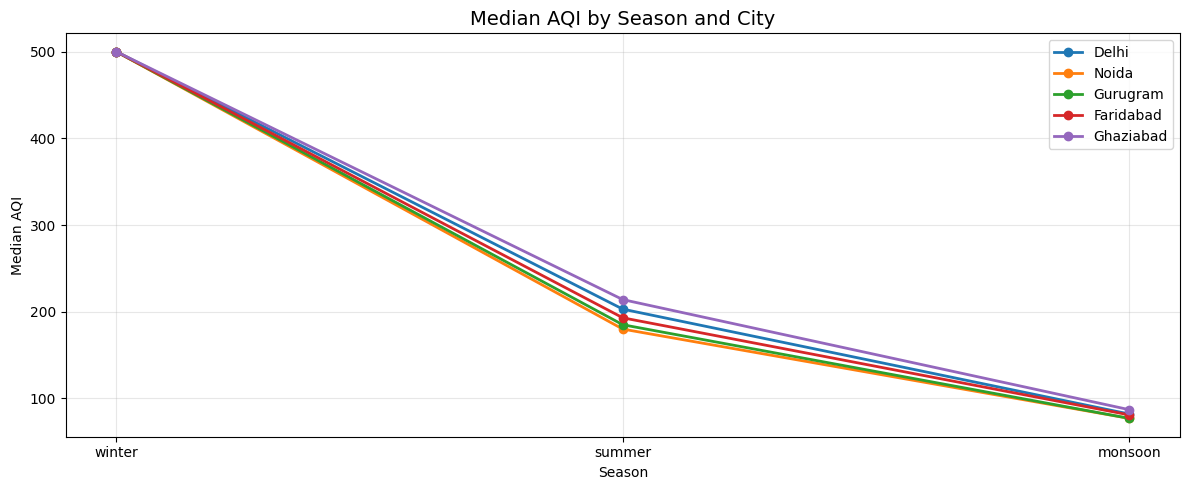


Seasonal AQI medians:
                mean    50%    min    max
season                                  
monsoon       82.90  82.00  25.00 263.00
post_monsoon 421.80 426.00 263.00 500.00
summer       204.80 198.00  73.00 376.00
winter       457.80 500.00 304.00 500.00


In [ ]:
season_order = ['winter', 'spring', 'summer', 'monsoon', 'autumn']

# Check what season labels exist in your data
print("Seasons in data:", df['season'].unique())

seasonal = df.groupby(['season', 'city'])['aqi'].median().reset_index()

plt.figure(figsize=(12, 5))
for city in df['city'].unique():
    data = seasonal[seasonal['city'] == city]
    # reorder by season
    data = data.set_index('season').reindex(
        [s for s in season_order if s in df['season'].unique()]
    ).reset_index()
    plt.plot(data['season'], data['aqi'], marker='o', label=city, linewidth=2)

plt.title('Median AQI by Season and City', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Median AQI')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSeasonal AQI medians:\n",
      df.groupby('season')['aqi'].describe()[['mean','50%','min','max']].round(1))

 Monthly granularity (find the exact spike months)

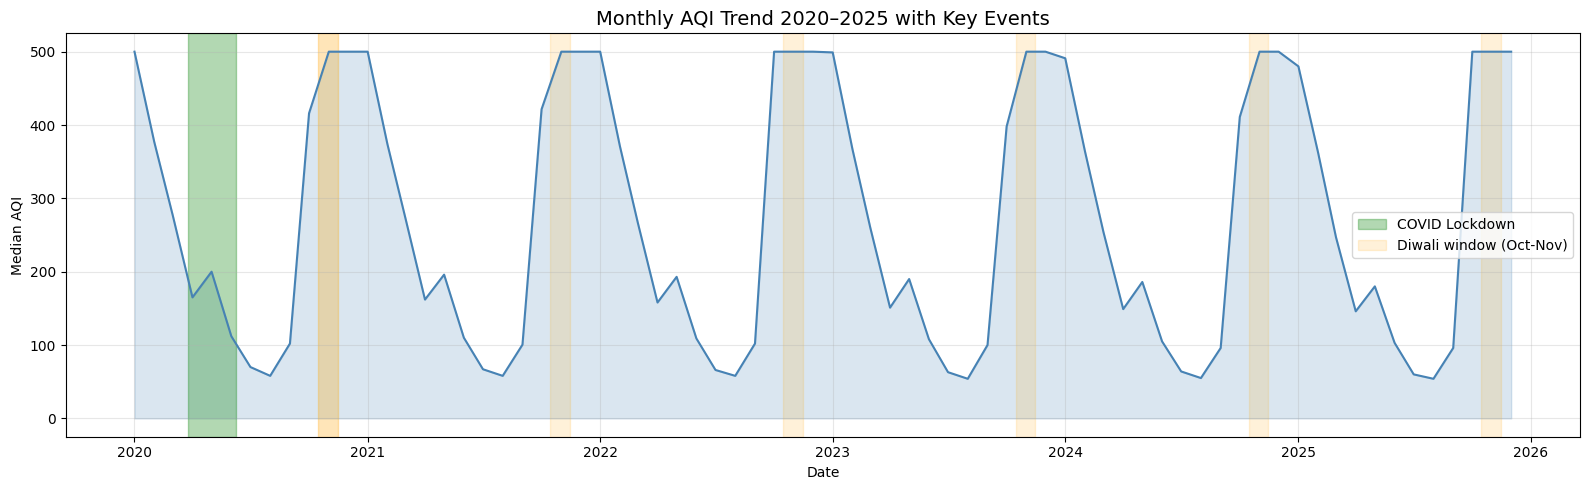

In [ ]:
monthly = df.groupby(['year', 'month'])['aqi'].median().reset_index()
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))

plt.figure(figsize=(16, 5))
plt.plot(monthly['date'], monthly['aqi'], color='steelblue', linewidth=1.5)
plt.fill_between(monthly['date'], monthly['aqi'], alpha=0.2, color='steelblue')

# Mark COVID lockdown
plt.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-06-08'),
            alpha=0.3, color='green', label='COVID Lockdown')

# Mark Diwali approximate windows (Oct-Nov each year)
for year in range(2020, 2026):
    plt.axvspan(pd.Timestamp(f'{year}-10-15'), pd.Timestamp(f'{year}-11-15'),
                alpha=0.15, color='orange')

plt.axvspan(pd.Timestamp('2020-10-15'), pd.Timestamp('2020-11-15'),
            alpha=0.15, color='orange', label='Diwali window (Oct-Nov)')

plt.title('Monthly AQI Trend 2020–2025 with Key Events', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Median AQI')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

COVID lockdown deep dive

COVID Period Comparison:
                  aqi   pm25   pm10   no2   so2   co    o3
period                                                   
Lockdown      162.00  78.60 148.40 28.00  6.40 1.20 33.60
Normal        276.00 112.70 212.60 39.70  9.30 1.80 37.10
Post-Lockdown 260.50 108.00 202.50 44.20  9.40 1.80 19.90
Pre-Lockdown  442.00 245.00 463.50 90.70 20.20 4.00 23.30


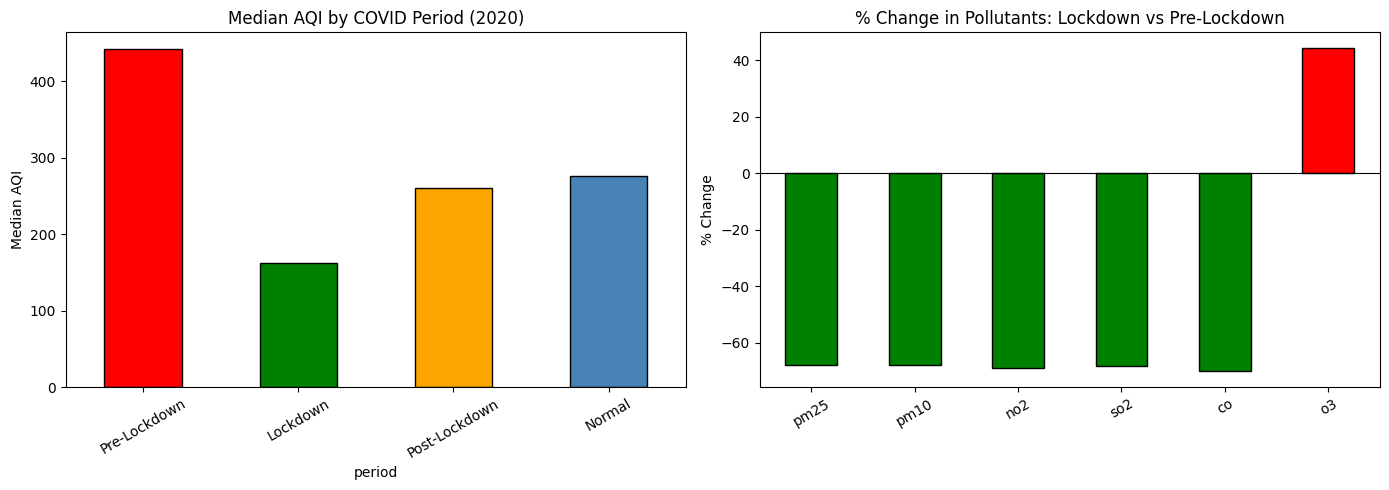

In [ ]:
# Isolate 2020, compare pre/during/post lockdown

# This approach was later discarded since this change in pollutants is majorly seasonal

df_2020 = df[df['year'] == 2020].copy()

# Define periods
df_2020['period'] = 'Normal'
df_2020.loc[(df_2020['month'] >= 3) & (df_2020['month'] < 4) &
             (df_2020['day'] >= 25), 'period'] = 'Lockdown'
df_2020.loc[(df_2020['month'] > 3) & (df_2020['month'] <= 6), 'period'] = 'Lockdown'
df_2020.loc[df_2020['month'] > 6, 'period'] = 'Post-Lockdown'
df_2020.loc[df_2020['month'] < 3, 'period'] = 'Pre-Lockdown'

period_order = ['Pre-Lockdown', 'Lockdown', 'Post-Lockdown', 'Normal']
lockdown_stats = df_2020.groupby('period')[
    ['aqi','pm25','pm10','no2','so2','co','o3']
].median().round(1)
print("COVID Period Comparison:\n", lockdown_stats)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AQI by period
period_aqi = df_2020.groupby('period')['aqi'].median().reindex(
    [p for p in period_order if p in df_2020['period'].unique()]
)
period_aqi.plot(kind='bar', ax=axes[0], color=['red','green','orange','steelblue'],
                edgecolor='black')
axes[0].set_title('Median AQI by COVID Period (2020)')
axes[0].set_ylabel('Median AQI')
axes[0].tick_params(axis='x', rotation=30)

# Pollutant % change during lockdown vs pre-lockdown
pre = lockdown_stats.loc['Pre-Lockdown']
lock = lockdown_stats.loc['Lockdown']
pct_change = ((lock - pre) / pre * 100).drop('aqi')
pct_change.plot(kind='bar', ax=axes[1],
                color=['green' if x < 0 else 'red' for x in pct_change],
                edgecolor='black')
axes[1].set_title('% Change in Pollutants: Lockdown vs Pre-Lockdown')
axes[1].set_ylabel('% Change')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

 Diurnal pattern (6am vs 12pm vs 6pm vs 11pm)

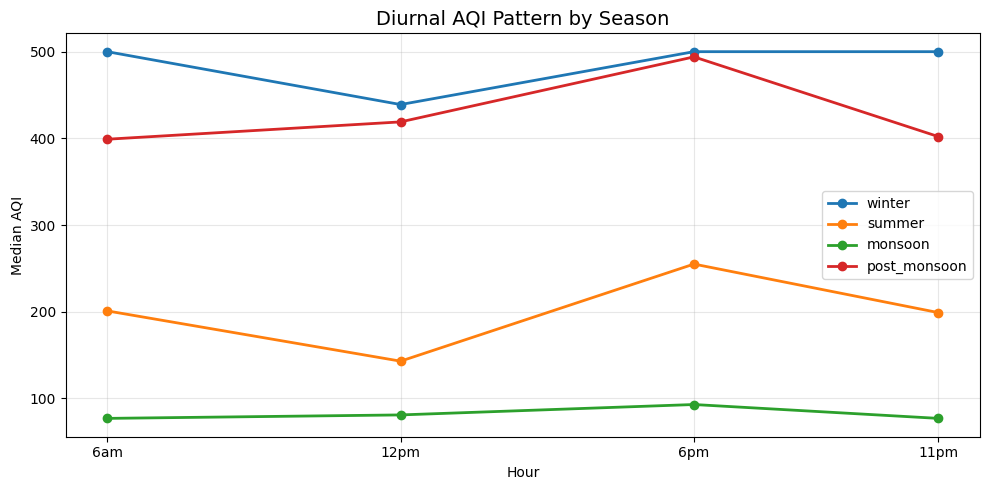

In [ ]:
diurnal = df.groupby(['hour', 'season'])['aqi'].median().reset_index()

plt.figure(figsize=(10, 5))
for season in df['season'].unique():
    data = diurnal[diurnal['season'] == season]
    plt.plot(data['hour'], data['aqi'], marker='o', label=season, linewidth=2)

plt.title('Diurnal AQI Pattern by Season', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Median AQI')
plt.xticks([6, 12, 18, 23], ['6am', '12pm', '6pm', '11pm'])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Spatial EDA (station hotspots, geographic patterns)

Station-level AQI ranking (who are the worst offenders?)

In [ ]:
station_aqi = df.groupby(['city', 'station']).agg(
    median_aqi=('aqi', 'median'),
    mean_aqi=('aqi', 'mean'),
    severe_pct=('aqi_category', lambda x: (x == 'Severe').sum() / len(x) * 100),
    lat=('latitude', 'first'),
    lon=('longitude', 'first')
).round(1).reset_index().sort_values('median_aqi', ascending=False)

print(station_aqi[['city','station','median_aqi','mean_aqi','severe_pct']].to_string())

         city               station  median_aqi  mean_aqi  severe_pct
0       Delhi    Anand Vihar, Delhi      298.00    295.20       36.10
4       Delhi   Jahangirpuri, Delhi      287.00    289.70       35.10
13      Delhi       Wazirpur, Delhi      277.00    286.60       34.30
1       Delhi         Bawana, Delhi      270.00    283.70       33.90
16  Ghaziabad        Ghaziabad Loni      262.00    279.60       32.90
3       Delhi            ITO, Delhi      252.00    277.00       32.40
7       Delhi  Okhla Phase 2, Delhi      250.00    274.10       32.00
17  Ghaziabad  Ghaziabad Vasundhara      240.00    270.60       31.10
8       Delhi   Punjabi Bagh, Delhi      239.00    270.30       31.00
15  Faridabad     Faridabad Sec 16A      232.00    266.10       30.10
11      Delhi       Shadipur, Delhi      230.00    266.10       30.10
22      Noida          Noida Sec 62      225.00    263.20       29.50
10      Delhi         Rohini, Delhi      225.00    263.00       29.40
14  Faridabad    Far

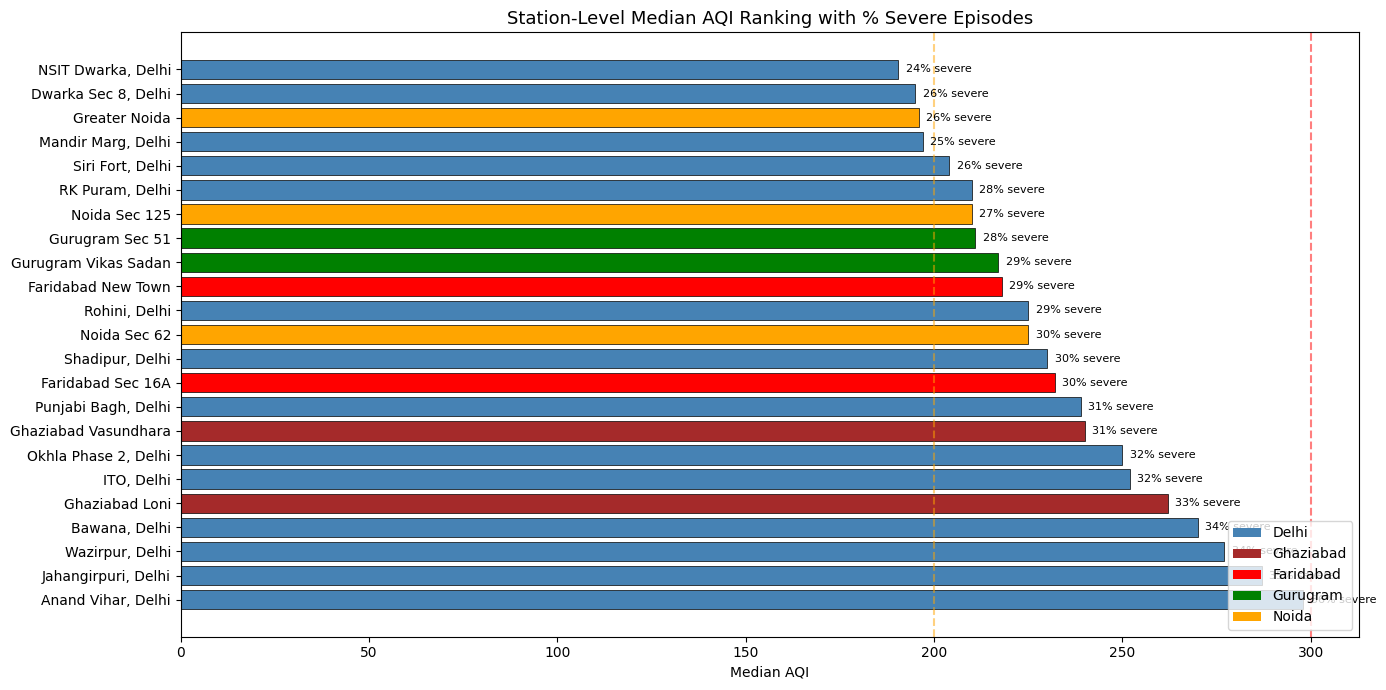

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = {'Delhi': 'steelblue', 'Ghaziabad': 'brown',
          'Faridabad': 'red', 'Gurugram': 'green', 'Noida': 'orange'}

bar_colors = [colors[city] for city in station_aqi['city']]
bars = ax.barh(station_aqi['station'], station_aqi['median_aqi'],
               color=bar_colors, edgecolor='black', linewidth=0.5)

# Add severe % labels
for i, (_, row) in enumerate(station_aqi.iterrows()):
    ax.text(row['median_aqi'] + 2, i, f"{row['severe_pct']:.0f}% severe",
            va='center', fontsize=8)

ax.axvline(300, color='red', linestyle='--', alpha=0.5, label='AQI=300 (Very Poor)')
ax.axvline(200, color='orange', linestyle='--', alpha=0.5, label='AQI=200 (Poor)')
ax.set_xlabel('Median AQI')
ax.set_title('Station-Level Median AQI Ranking with % Severe Episodes', fontsize=13)

# Legend for cities
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# How Pollutant Mixes Differ Across Stations

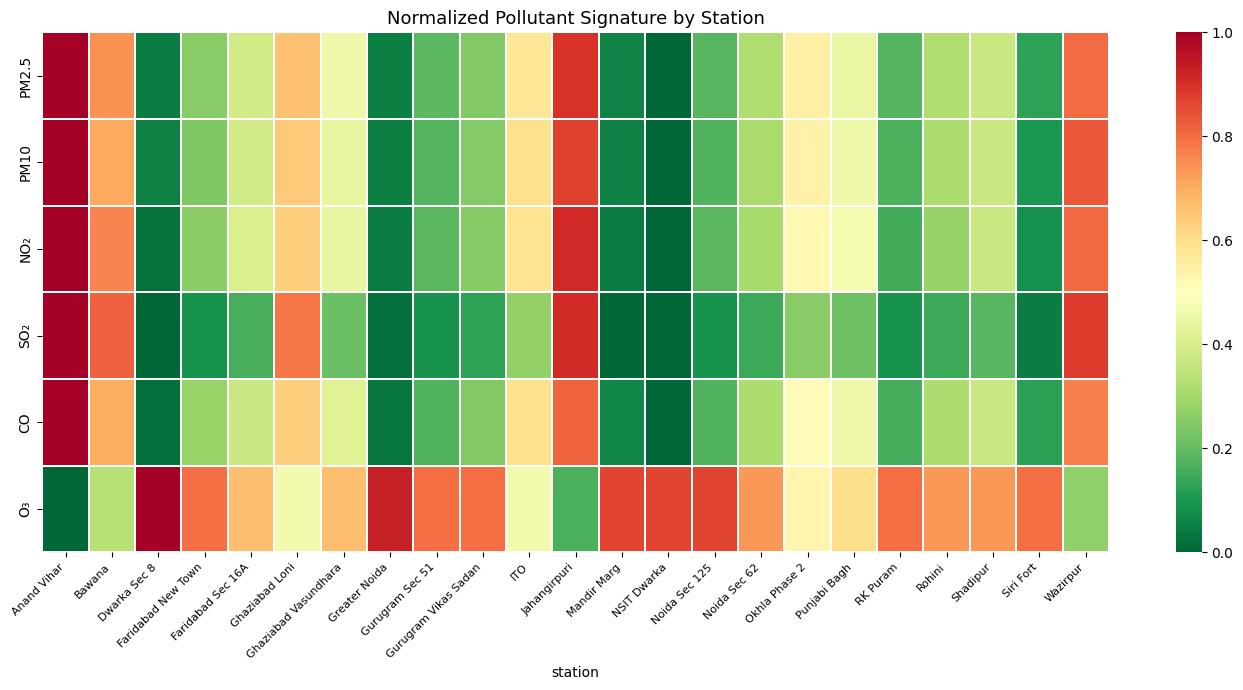

In [ ]:
station_poll = df.groupby('station')[['pm25','pm10','no2','so2','co','o3']].median()

# Normalize for comparison
station_poll_norm = (station_poll - station_poll.min()) / (station_poll.max() - station_poll.min())

plt.figure(figsize=(14, 7))
sns.heatmap(station_poll_norm.T,
            cmap='RdYlGn_r',
            annot=False,
            linewidths=0.3,
            xticklabels=[s.replace(', Delhi','').replace(' Delhi','')
                         for s in station_poll_norm.index],
            yticklabels=['PM2.5','PM10','NO₂','SO₂','CO','O₃'])

plt.title('Normalized Pollutant Signature by Station', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

#PREPROCESSING

In [ ]:
df = df.drop(columns=['wind_bin', 'hum_bin'])

Validating dataset before engineering

In [ ]:
assert df.shape[0] == 201664,   f"Row count wrong: {df.shape[0]}"
assert df.shape[1] == 25,       f"Column count wrong: {df.shape[1]}"
assert df.isnull().sum().sum() == 0, "Raw file has nulls — unexpected"
assert sorted(df['year'].unique()) == [2020,2021,2022,2023,2024,2025], \
    f"Years wrong: {sorted(df['year'].unique())}"
assert df['station'].nunique() == 23, \
    f"Station count wrong: {df['station'].nunique()}"
assert df['city'].nunique() == 5, \
    f"City count wrong: {df['city'].nunique()}"
assert set(df['hour'].unique()) == {6, 12, 18, 23}, \
    f"Unexpected hours: {df['hour'].unique()}"

print("✓ Raw dataset validated")
print(f"  Shape   : {df.shape}")
print(f"  Years   : {sorted(df['year'].unique())}")
print(f"  Cities  : {sorted(df['city'].unique())}")
print(f"  Stations: {df['station'].nunique()}")
print(f"  Hours   : {sorted(df['hour'].unique())}")


✓ Raw dataset validated
  Shape   : (201664, 25)
  Years   : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Cities  : ['Delhi', 'Faridabad', 'Ghaziabad', 'Gurugram', 'Noida']
  Stations: 23
  Hours   : [np.int64(6), np.int64(12), np.int64(18), np.int64(23)]


In [ ]:
df.head()

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.60,47.70,5.19,12.30,9.40,100,3.60,1.20,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.90,39.30,4.32,15.80,20.60,50,5.90,1.40,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.10,36.30,7.13,14.30,12.40,56,4.50,1.10,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.00,30.30,4.90,13.20,14.40,48,5.80,1.40,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.40,41.50,7.56,15.40,6.80,100,2.80,0.40,500,Severe


#Feature Engineerigng

Handling Datetime Feature

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
# Sort by station then time so lag features stay within station
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)

In [ ]:
# Verify sort is correct
assert df.groupby('station')['datetime'].is_monotonic_increasing.all(), \
    "Sort failed — datetime not monotonic within stations"

print("✓ Types fixed and data sorted")
print(f"  datetime range : {df['datetime'].min()} → {df['datetime'].max()}")


✓ Types fixed and data sorted
  datetime range : 2020-01-01 06:00:00 → 2025-12-31 23:00:00


Cyclical time encodings

In [ ]:
# Raw hour/month are circular — hour 23 and hour 0 are adjacent.
# Encoding as sin+cos preserves this circular distance correctly.
# Linear models and neural nets benefit most from this.

df['hour_sin']    = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)

df['day_of_year'] = df['datetime'].dt.dayofyear
df['doy_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365)

print("✓ Cyclical encodings added")
print(f"  New columns : hour_sin, hour_cos, month_sin, month_cos, "
      f"doy_sin, doy_cos")

✓ Cyclical encodings added
  New columns : hour_sin, hour_cos, month_sin, month_cos, doy_sin, doy_cos


Categorical encodings


In [ ]:
# Label encode city and station.
# Save the mappings explicitly — needed for model interpretation.

df['season_enc'] = df['season'].map({
    'winter'      : 0,
    'summer'      : 1,
    'monsoon'     : 2,
    'post_monsoon': 3
})

assert df['season_enc'].isna().sum() == 0, \
    f"Unmapped season values: {df[df['season_enc'].isna()]['season'].unique()}"

le_city    = LabelEncoder()
le_station = LabelEncoder()

df['city_enc']    = le_city.fit_transform(df['city'])
df['station_enc'] = le_station.fit_transform(df['station'])

In [ ]:
#   aqi          → main regression target (raw, has 500 ceiling)
#   is_severe    → binary classification (AQI ≥ 300)
#                  Policy-relevant: predict severe episodes in advance.

In [ ]:
df['aqi_capped'] = df['aqi'].clip(upper=400)
df['is_severe']  = (df['aqi'] >= 300).astype(int)

print("✓ Target variants created")
print(f"  aqi         : min={df['aqi'].min()}  "
      f"max={df['aqi'].max()}  "
      f"mean={df['aqi'].mean():.1f}")
print(f"  aqi_capped  : min={df['aqi_capped'].min()}  "
      f"max={df['aqi_capped'].max()}  "
      f"mean={df['aqi_capped'].mean():.1f}")
print(f"  is_severe   : {df['is_severe'].sum():,} positives  "
      f"({df['is_severe'].mean()*100:.1f}%)")

assert df['aqi_capped'].max() == 400, "aqi_capped clip failed"
assert df['is_severe'].isin([0,1]).all(), "is_severe has non-binary values"


✓ Target variants created
  aqi         : min=25  max=500  mean=265.8
  aqi_capped  : min=25  max=400  mean=239.8
  is_severe   : 90,066 positives  (44.7%)


Event flags

In [ ]:
# Binary features for known pollution events.
# Also used as grouping variables in causal analysis section.
#
# is_lockdown      : COVID lockdown (Mar 25 – Jun 8 2020)
#                    Natural experiment — human activity near zero
# is_diwali_window : Oct 15 – Nov 15 each year
#                    Firecracker emissions + post-monsoon inversion
# is_stubble_season: Oct–Nov — crop burning in Punjab/Haryana
#                    Overlaps with Diwali; separate flag for analysis

In [ ]:
df['is_lockdown'] = (
    (df['datetime'] >= '2020-03-25') &
    (df['datetime'] <= '2020-06-08')
).astype(int)

df['is_diwali_window'] = (
    ((df['month'] == 10) & (df['day'] >= 15)) |
    ((df['month'] == 11) & (df['day'] <= 15))
).astype(int)

df['is_stubble_season'] = df['month'].isin([10, 11]).astype(int)


In [ ]:
# Verify lockdown count: 75 days × 4 snapshots × 23 stations = 6,900
# Verify lockdown count: 75 days × 4 snapshots × 23 stations = 6,900
assert df['is_lockdown'].sum() == 6900, \
    f"Lockdown row count wrong: {df['is_lockdown'].sum()}"

print("✓ Event flags added")
print(df[['is_lockdown','is_diwali_window','is_stubble_season']].sum().rename('total rows'))

✓ Event flags added
is_lockdown           6900
is_diwali_window     17664
is_stubble_season    33672
Name: total rows, dtype: int64


Derived ratio features

#Q1: What are the dominant pollution profiles across Delhi NCR monitoring stations? Are all stations equally polluted or are some structurally worse?

# K-Means Station Clustering

Silhouette scores by k:
  k=2 : 0.6089
  k=3 : 0.5469
  k=4 : 0.4992
  k=5 : 0.4584
  k=6 : 0.4521

Best k : 2

Stations per cluster:
cluster
0    10
1     5
2     8
Name: count, dtype: int64

Cluster assignments:
                      cluster
station                      
Faridabad New Town          0
Dwarka Sec 8, Delhi         0
Greater Noida               0
Noida Sec 125               0
Mandir Marg, Delhi          0
NSIT Dwarka, Delhi          0
Gurugram Vikas Sadan        0
Gurugram Sec 51             0
Siri Fort, Delhi            0
RK Puram, Delhi             0
Bawana, Delhi               1
Jahangirpuri, Delhi         1
Ghaziabad Loni              1
Wazirpur, Delhi             1
Anand Vihar, Delhi          1
Ghaziabad Vasundhara        2
Noida Sec 62                2
ITO, Delhi                  2
Faridabad Sec 16A           2
Okhla Phase 2, Delhi        2
Rohini, Delhi               2
Punjabi Bagh, Delhi         2
Shadipur, Delhi             2

Cluster centroids (median pollutant

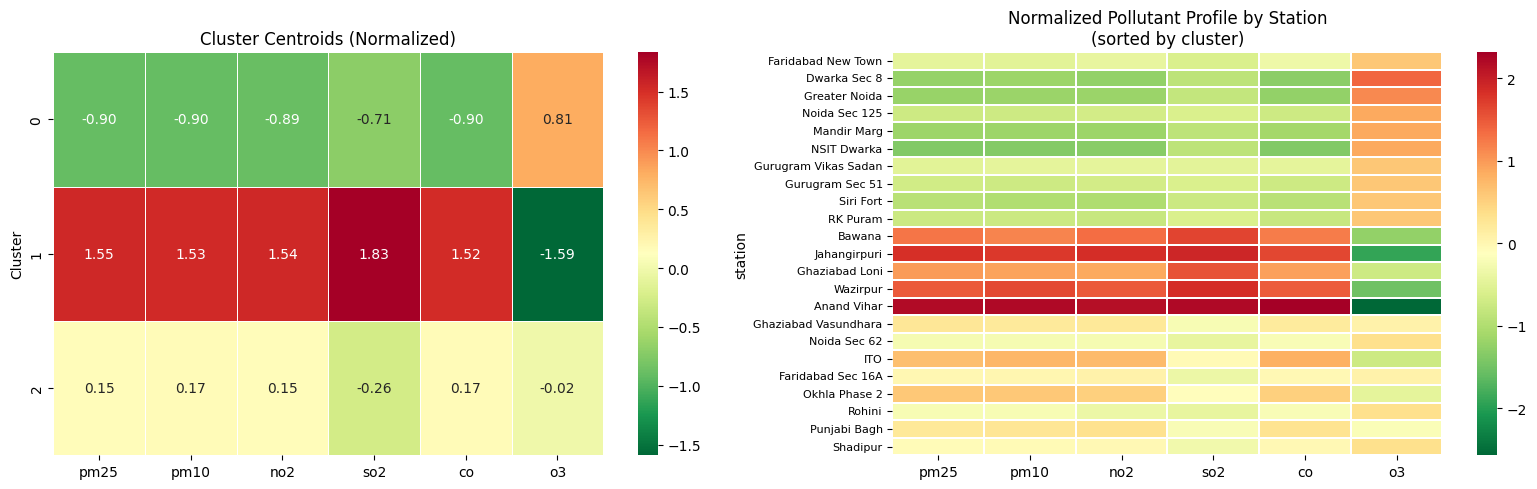


✓ station_cluster added to df
station_cluster
0    87680
1    43840
2    70144
Name: count, dtype: int64

Final cluster interpretation:

  Cluster 0 — clean:
    Dwarka Sec 8, Delhi
    Faridabad New Town
    Greater Noida
    Gurugram Sec 51
    Gurugram Vikas Sadan
    Mandir Marg, Delhi
    NSIT Dwarka, Delhi
    Noida Sec 125
    RK Puram, Delhi
    Siri Fort, Delhi

  Cluster 1 — high_emission:
    Anand Vihar, Delhi
    Bawana, Delhi
    Ghaziabad Loni
    Jahangirpuri, Delhi
    Wazirpur, Delhi

  Cluster 2 — mixed_urban:
    Faridabad Sec 16A
    Ghaziabad Vasundhara
    ITO, Delhi
    Noida Sec 62
    Okhla Phase 2, Delhi
    Punjabi Bagh, Delhi
    Rohini, Delhi
    Shadipur, Delhi


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── Step 1: Station pollutant profiles (median per station) ──
POLLUTANTS = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

station_profiles = df.groupby('station')[POLLUTANTS].median()

# ── Step 2: Normalize (shape matters, not magnitude) ─────────
scaler = StandardScaler()
X_cluster = scaler.fit_transform(station_profiles)

# ── Step 3: Find optimal k using silhouette score ─────────────
sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, labels)

print("Silhouette scores by k:")
for k, s in sil_scores.items():
    print(f"  k={k} : {s:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k : {best_k}")

# ── Step 4: Fit final model with best k ───────────────────────
# Force k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
station_profiles['cluster'] = kmeans.fit_predict(X_cluster)

print("\nStations per cluster:")
print(station_profiles['cluster'].value_counts().sort_index())

print("\nCluster assignments:")
print(station_profiles[['cluster']].sort_values('cluster').to_string())

# ── Step 5: Interpret clusters via centroids ──────────────────
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=POLLUTANTS
).round(1)
centroids.index.name = 'cluster'
print("\nCluster centroids (median pollutant levels):")
print(centroids)

# ── Step 6: Visualize cluster profiles ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap of normalized centroids
sns.heatmap(
    pd.DataFrame(kmeans.cluster_centers_, columns=POLLUTANTS),
    annot=True, fmt='.2f', cmap='RdYlGn_r',
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Cluster Centroids (Normalized)', fontsize=12)
axes[0].set_ylabel('Cluster')

# Station-level heatmap with cluster labels
station_norm = pd.DataFrame(X_cluster, columns=POLLUTANTS,
                             index=station_profiles.index)
station_norm['cluster'] = station_profiles['cluster']
station_norm = station_norm.sort_values('cluster')

sns.heatmap(
    station_norm[POLLUTANTS],
    cmap='RdYlGn_r', linewidths=0.3,
    ax=axes[1],
    xticklabels=POLLUTANTS,
    yticklabels=[s.replace(', Delhi','') for s in station_norm.index]
)
axes[1].set_title('Normalized Pollutant Profile by Station\n(sorted by cluster)', fontsize=12)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('station_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Step 7: Map cluster back to main df ──────────────────────
cluster_map = station_profiles['cluster'].to_dict()
df['station_cluster'] = df['station'].map(cluster_map)

assert df['station_cluster'].isna().sum() == 0, \
    "Some stations didn't get a cluster — check station names"

print(f"\n✓ station_cluster added to df")
print(df['station_cluster'].value_counts().sort_index())

# ── Step 8: Label clusters ────────────────────────────────────
CLUSTER_LABELS = {0: 'clean', 1: 'high_emission', 2: 'mixed_urban'}

print("\nFinal cluster interpretation:")
for k, label in CLUSTER_LABELS.items():
    stations = station_profiles[station_profiles['cluster']==k].index.tolist()
    print(f"\n  Cluster {k} — {label}:")
    for s in stations:
        print(f"    {s}")

#ALL ML MODELS COMPARISON

##Dataset - all features

In [ ]:
FEATURES_ALL = [
    # Pollutants (6)
    'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',

    # Weather (4)
    'temperature', 'humidity', 'wind_speed', 'visibility',

    # Cyclical time (6)
    'hour_sin', 'hour_cos',
    'doy_sin', 'doy_cos',
    'month_sin', 'month_cos',

    # Calendar (2)
    'is_weekend',
    'season_enc',

    # Spatial (3)
    'city_enc',
    'station_enc',
    'station_cluster',

    # Event flags (3)
    'is_lockdown',
    'is_diwali_window',
    'is_stubble_season'
]


# ── Build modeling dataframe ─────────────────────────────────
df_model = df.dropna(subset=FEATURES_ALL).copy()

rows_dropped = len(df) - len(df_model)

assert rows_dropped <= 100, f"Too many rows dropped: {rows_dropped}"
assert df_model[FEATURES_ALL].isna().sum().sum() == 0
assert sorted(df_model['year'].unique()) == [2020, 2021, 2022, 2023, 2024, 2025]

print(f"✓ df_model built")
print(f"  Rows dropped   : {rows_dropped}")
print(f"  df_model shape : {df_model.shape}")
print(f"  Years present  : {sorted(df_model['year'].unique())}")

print(
    df_model['year']
    .value_counts()
    .sort_index()
)

✓ df_model built
  Rows dropped   : 0
  df_model shape : (201664, 41)
  Years present  : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
year
2020    33672
2021    33580
2022    33580
2023    33580
2024    33672
2025    33580
Name: count, dtype: int64


Train Test Split

In [ ]:
# ── Train/Test Split ─────────────────────────────────────────
LOCKDOWN_START = '2020-03-25'
LOCKDOWN_END   = '2020-06-08'

train_all = df_model[
    df_model['year'] <= 2023
].copy()

lockdown_mask = (
    (train_all['datetime'] >= LOCKDOWN_START)
    &
    (train_all['datetime'] <= LOCKDOWN_END)
)

train = train_all[
    ~lockdown_mask
].copy()

test = df_model[
    df_model['year'] >= 2024
].copy()


X_train = train[FEATURES_ALL]
X_test  = test[FEATURES_ALL]

y_train_aqi = train['aqi']
y_test_aqi  = test['aqi']

y_train_severe = train['is_severe']
y_test_severe  = test['is_severe']


assert len(test) > 0
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert train['is_lockdown'].sum() == 0


print(f"✓ Split complete")
print(f"  Lockdown rows excluded : {lockdown_mask.sum():,}")

print(
    f"  Train : {len(train):,} rows "
    f"({train['year'].min()}–{train['year'].max()})"
)

print(
    f"  Test  : {len(test):,} rows "
    f"({test['year'].min()}–{test['year'].max()})"
)

print(
    f"  NaNs X_train : "
    f"{X_train.isna().sum().sum()}"
)

print(
    f"  NaNs X_test  : "
    f"{X_test.isna().sum().sum()}"
)

print(
    f"\n  Train AQI — mean: "
    f"{y_train_aqi.mean():.1f}  "
    f"median: {y_train_aqi.median():.1f}"
)

print(
    f"  Test  AQI — mean: "
    f"{y_test_aqi.mean():.1f}  "
    f"median: {y_test_aqi.median():.1f}"
)

print(
    f"\n  Train severe rate : "
    f"{y_train_severe.mean()*100:.1f}%"
)

print(
    f"  Test  severe rate : "
    f"{y_test_severe.mean()*100:.1f}%"
)

✓ Split complete
  Lockdown rows excluded : 6,900
  Train : 127,512 rows (2020–2023)
  Test  : 67,252 rows (2024–2025)
  NaNs X_train : 0
  NaNs X_test  : 0

  Train AQI — mean: 272.3  median: 254.0
  Test  AQI — mean: 261.5  median: 221.0

  Train severe rate : 47.1%
  Test  severe rate : 43.9%


Defining Regression Metrics

In [ ]:
# ── Metrics Function ──────────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
def regression_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100

    print(f"\n  {label}")
    print(f"    R²   : {r2:.4f}")
    print(f"    RMSE : {rmse:.2f}")
    print(f"    MAE  : {mae:.2f}")
    print(f"    MAPE : {mape:.2f}%")

    return {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

##Linear Regression (All features, Target AQI)

=== LINEAR REGRESSION (All features, Target AQI) ===

  Train
    R²   : 0.9289
    RMSE : 46.47
    MAE  : 38.30
    MAPE : 25.62%

  Test
    R²   : 0.9256
    RMSE : 46.88
    MAE  : 38.63
    MAPE : 27.17%

  Overfitting gap (R² train-test) : 0.0033
  ✓ No significant overfit

  CV R² scores : [0.9245 0.909  0.93   0.9282]
  CV R² mean   : 0.9229 ± 0.0083

  Top 15 features by coefficient magnitude:
          feature  coefficient
        month_cos        54.04
       visibility       -41.51
             pm10        37.05
          doy_sin        26.31
          doy_cos        26.30
               o3       -22.26
is_stubble_season        19.55
      temperature       -13.62
        month_sin         9.39
         humidity        -9.23
 is_diwali_window         8.19
         hour_cos        -6.62
               co        -6.30
       season_enc         5.19
         hour_sin        -4.96


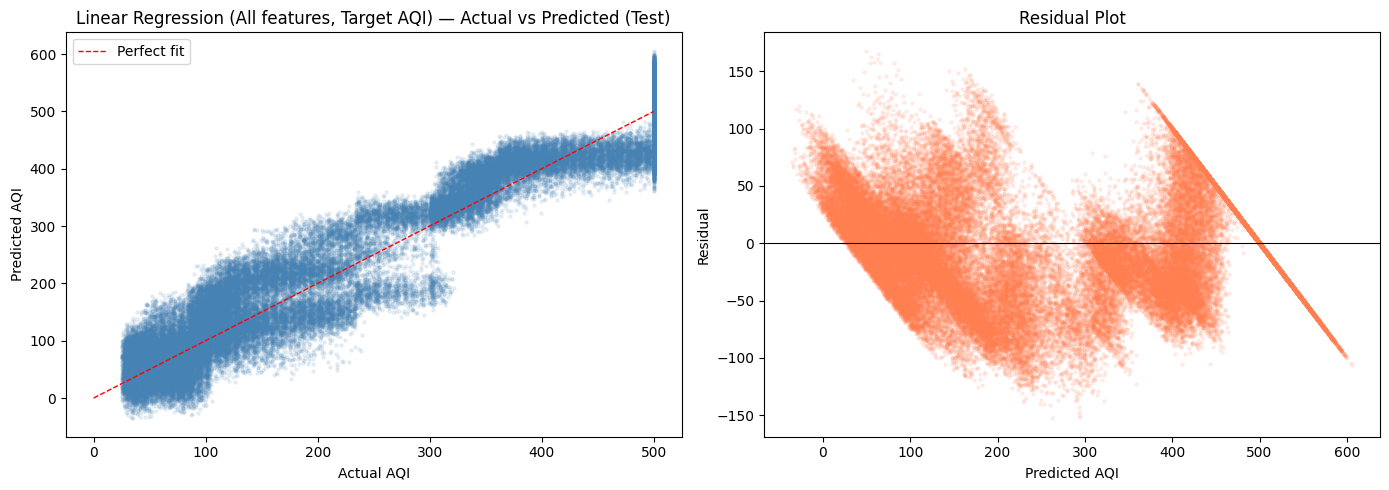


✓ Linear Regression (All features, Target AQI) complete


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ── Scale features (required for Linear Regression) ──────────
# Fit ONLY on training data — never on test
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ── Train ─────────────────────────────────────────────────────
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train_aqi
)


# ── Predict ───────────────────────────────────────────────────
y_pred_train = lr.predict(X_train_scaled)
y_pred_test  = lr.predict(X_test_scaled)


# ── Metrics ───────────────────────────────────────────────────
def regression_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs(
            (y_true - y_pred) /
            y_true.replace(0, np.nan)
        )
    ) * 100

    print(f"\n  {label}")
    print(f"    R²   : {r2:.4f}")
    print(f"    RMSE : {rmse:.2f}")
    print(f"    MAE  : {mae:.2f}")
    print(f"    MAPE : {mape:.2f}%")

    return {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }


print("=== LINEAR REGRESSION (All features, Target AQI) ===")

train_metrics_lr = regression_metrics(
    y_train_aqi,
    y_pred_train,
    "Train"
)

test_metrics_lr = regression_metrics(
    y_test_aqi,
    y_pred_test,
    "Test"
)


overfit_gap = train_metrics_lr['R2'] - test_metrics_lr['R2']

print(f"\n  Overfitting gap (R² train-test) : {overfit_gap:.4f}")
print(f"  {'⚠ Possible overfit' if overfit_gap > 0.05 else '✓ No significant overfit'}")


# ── Time-series cross validation ──────────────────────────────
tscv = TimeSeriesSplit(n_splits=4)

cv_scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train_aqi,
    cv=tscv,
    scoring='r2'
)

print(f"\n  CV R² scores : {cv_scores.round(4)}")
print(f"  CV R² mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ── Coefficients (top 15 by absolute value) ───────────────────
coef_df = pd.DataFrame({
    'feature': FEATURES_ALL,
    'coefficient': lr.coef_
}).reindex(
    pd.Series(lr.coef_)
      .abs()
      .sort_values(ascending=False)
      .index
).head(15)

print(f"\n  Top 15 features by coefficient magnitude:")
print(coef_df.to_string(index=False))


# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Actual vs predicted
axes[0].scatter(
    y_test_aqi,
    y_pred_test,
    alpha=0.1,
    s=5,
    color='steelblue'
)

axes[0].plot(
    [0, 500],
    [0, 500],
    'r--',
    linewidth=1,
    label='Perfect fit'
)

axes[0].set_xlabel('Actual AQI')
axes[0].set_ylabel('Predicted AQI')
axes[0].set_title(
    'Linear Regression (All features, Target AQI) — Actual vs Predicted (Test)'
)
axes[0].legend()


# Residuals
residuals = y_test_aqi - y_pred_test

axes[1].scatter(
    y_pred_test,
    residuals,
    alpha=0.1,
    s=5,
    color='coral'
)

axes[1].axhline(
    0,
    color='black',
    linewidth=0.8
)

axes[1].set_xlabel('Predicted AQI')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')


plt.tight_layout()

plt.savefig(
    'lr_no_lags_no_ratios.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


print("\n✓ Linear Regression (All features, Target AQI) complete")

##Random Forest- (All Features, Target AQI)

*Data Leakage Issue*


=== RANDOM FOREST REGRESSOR (All Features, Target AQI) ===

  Train
    R²   : 1.0000
    RMSE : 0.04
    MAE  : 0.00
    MAPE : 0.00%

  Test
    R²   : 1.0000
    RMSE : 0.06
    MAE  : 0.01
    MAPE : 0.01%

  Overfitting gap (R² train-test) : 0.0000
  ✓ No significant overfit

  CV R² scores : [1. 1. 1. 1.]
  CV R² mean   : 1.0000 ± 0.0000

  Top 15 features by importance:
        feature  importance
           pm25        0.91
           pm10        0.09
    temperature        0.00
             co        0.00
            no2        0.00
     visibility        0.00
     wind_speed        0.00
             o3        0.00
       humidity        0.00
            so2        0.00
    station_enc        0.00
        doy_cos        0.00
        doy_sin        0.00
station_cluster        0.00
       city_enc        0.00


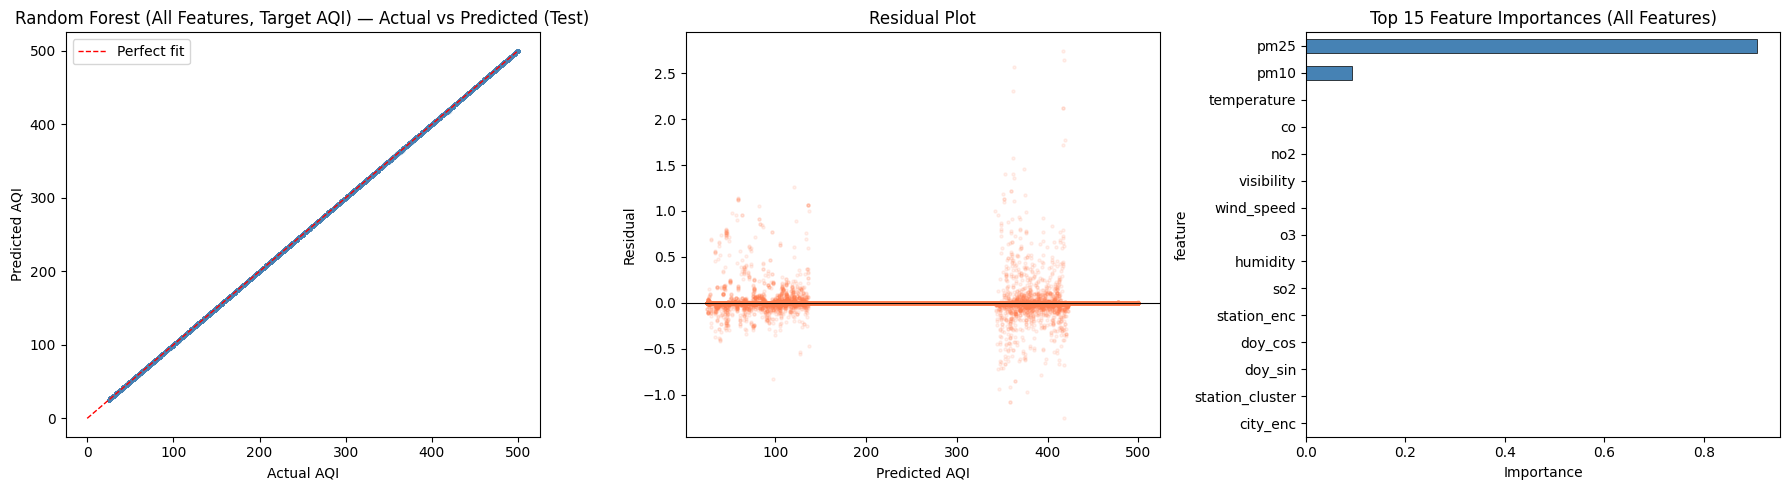


✓ Random Forest (All Features, Target AQI) complete


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ── Train ─────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train_aqi)


# ── Predict ───────────────────────────────────────────────────
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf  = rf.predict(X_test)


# ── Metrics ───────────────────────────────────────────────────
def regression_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100

    print(f"\n  {label}")
    print(f"    R²   : {r2:.4f}")
    print(f"    RMSE : {rmse:.2f}")
    print(f"    MAE  : {mae:.2f}")
    print(f"    MAPE : {mape:.2f}%")

    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


# ── Evaluation ───────────────────────────────────────────────
print("=== RANDOM FOREST REGRESSOR (All Features, Target AQI) ===")

train_metrics_rf = regression_metrics(y_train_aqi, y_pred_train_rf, "Train")
test_metrics_rf  = regression_metrics(y_test_aqi,  y_pred_test_rf,  "Test")

overfit_gap = train_metrics_rf['R2'] - test_metrics_rf['R2']

print(f"\n  Overfitting gap (R² train-test) : {overfit_gap:.4f}")
print(f"  {'⚠ Possible overfit' if overfit_gap > 0.05 else '✓ No significant overfit'}")


# ── Cross validation ──────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=4)

cv_scores = cross_val_score(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    X_train,
    y_train_aqi,
    cv=tscv,
    scoring='r2'
)

print(f"\n  CV R² scores : {cv_scores.round(4)}")
print(f"  CV R² mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ── Feature importance ────────────────────────────────────────
feat_imp = pd.DataFrame({
    'feature': FEATURES_ALL,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n  Top 15 features by importance:")
print(feat_imp.head(15).to_string(index=False))


# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Actual vs predicted
axes[0].scatter(y_test_aqi, y_pred_test_rf, alpha=0.1, s=5, color='steelblue')
axes[0].plot([0, 500], [0, 500], 'r--', linewidth=1, label='Perfect fit')
axes[0].set_xlabel('Actual AQI')
axes[0].set_ylabel('Predicted AQI')
axes[0].set_title('Random Forest (All Features, Target AQI) — Actual vs Predicted (Test)')
axes[0].legend()


# Residuals
residuals_rf = y_test_aqi - y_pred_test_rf
axes[1].scatter(y_pred_test_rf, residuals_rf, alpha=0.1, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Predicted AQI')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')


# Feature importance
feat_imp.head(15).plot(
    kind='barh',
    x='feature',
    y='importance',
    ax=axes[2],
    color='steelblue',
    edgecolor='black',
    linewidth=0.5
)

axes[2].invert_yaxis()
axes[2].set_title('Top 15 Feature Importances (All Features)')
axes[2].set_xlabel('Importance')
axes[2].legend().remove()


plt.tight_layout()
plt.savefig('rf_all_features_aqi.png', dpi=150, bbox_inches='tight')
plt.show()


print("\n✓ Random Forest (All Features, Target AQI) complete")

Since AQI is directly derived from PM2.5 it cause leakage

Hence- Changing the target to PM2.5

Checking if PM2.5 is also capped

In [ ]:
print("PM2.5 stats:")
print(df['pm25'].describe().round(2))


# ── PM2.5 CAPPING ANALYSIS ──────────────────────────────────────────
pm25_max = df['pm25'].max()

capped_mask = df['pm25'] == pm25_max
capped_count = capped_mask.sum()
total_count = len(df)

capped_percent = (capped_count / total_count) * 100


print(f"\nPM2.5 max value: {pm25_max}")
print(f"Records at capped max value: {capped_count}")
print(f"Percentage of capped values: {capped_percent:.2f}%")

PM2.5 stats:
count   201664.00
mean       183.42
std        193.14
min         15.00
25%         55.30
50%         99.50
75%        254.70
max        900.00
Name: pm25, dtype: float64

PM2.5 max value: 900.0
Records at capped max value: 4543
Percentage of capped values: 2.25%


##Dataset- PM2.5 Target

In [ ]:
# ─────────────────────────────────────────────────────────────
# FEATURES
# ─────────────────────────────────────────────────────────────
FEATURES_PM25 = [
    'no2',
    'so2',
    'co',
    'o3',
    'temperature',
    'humidity',
    'wind_speed',
    'hour_sin',
    'hour_cos',
    'doy_sin',
    'doy_cos',
    'month_sin',
    'month_cos',
    'city_enc',
    'station_enc',
    'station_cluster',
    'is_lockdown',
    'is_diwali_window',
    'is_stubble_season'
]

##Linear Regression (Target PM2.5)

=== LINEAR REGRESSION (PM2.5 Prediction) ===

  Train
    R²   : 0.9771
    RMSE : 30.24
    MAE  : 19.12
    MAPE : 17.39%

  Test
    R²   : 0.9776
    RMSE : 28.00
    MAE  : 18.15
    MAPE : 18.00%

  Overfitting gap : -0.0004
  ✓ No significant overfit

  CV R² scores : [0.9717 0.9654 0.977  0.9765]
  CV R² mean   : 0.9727 ± 0.0047

  Top 15 PM2.5 features by coefficient magnitude:
          feature  coefficient
               co        69.92
              so2        57.48
              no2        50.56
        month_cos        43.87
      temperature        32.63
        month_sin        24.45
         humidity        18.45
         hour_sin        16.67
is_stubble_season        14.61
         hour_cos         9.98
 is_diwali_window         6.58
       wind_speed         5.85
               o3        -4.61
         city_enc         1.36
      station_enc         1.33


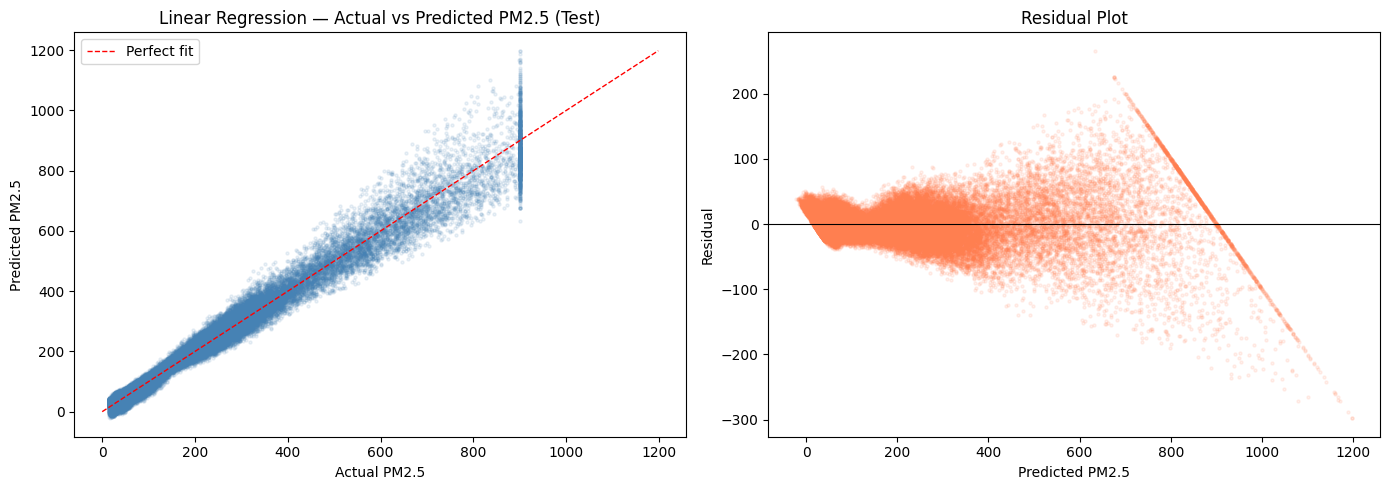

✓ Linear Regression PM2.5 complete


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ─────────────────────────────────────────────────────────────
# TRAIN / TEST
# Uses your existing train and test datasets
# (NO lockdown removal)
# ─────────────────────────────────────────────────────────────
X_train_PM25 = train[FEATURES_PM25]
X_test_PM25  = test[FEATURES_PM25]

y_train_PM25 = train['pm25']
y_test_PM25  = test['pm25']


# ─────────────────────────────────────────────────────────────
# SCALING
# ─────────────────────────────────────────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_PM25)
X_test_scaled  = scaler.transform(X_test_PM25)


# ─────────────────────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────────────────────
lr_PM25 = LinearRegression()
lr_PM25.fit(X_train_scaled, y_train_PM25)


# ─────────────────────────────────────────────────────────────
# PREDICT
# ─────────────────────────────────────────────────────────────
y_pred_train_PM25 = lr_PM25.predict(X_train_scaled)
y_pred_test_PM25  = lr_PM25.predict(X_test_scaled)


# ─────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────
print("=== LINEAR REGRESSION (PM2.5 Prediction) ===")

train_metrics_PM25 = regression_metrics(
    y_train_PM25,
    y_pred_train_PM25,
    "Train"
)

test_metrics_PM25 = regression_metrics(
    y_test_PM25,
    y_pred_test_PM25,
    "Test"
)

overfit_gap_PM25 = (
    train_metrics_PM25['R2']
    - test_metrics_PM25['R2']
)

print(f"\n  Overfitting gap : {overfit_gap_PM25:.4f}")
print(
    f"  {'⚠ Possible overfit' if overfit_gap_PM25 > 0.05 else '✓ No significant overfit'}"
)


# ─────────────────────────────────────────────────────────────
# TIME SERIES CROSS VALIDATION
# ─────────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=4)

cv_scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train_PM25,
    cv=tscv,
    scoring='r2'
)

print(f"\n  CV R² scores : {cv_scores.round(4)}")
print(f"  CV R² mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ─────────────────────────────────────────────────────────────
# COEFFICIENTS
# ─────────────────────────────────────────────────────────────
coef_df_PM25 = pd.DataFrame({
    'feature': FEATURES_PM25,
    'coefficient': lr_PM25.coef_
}).reindex(
    pd.Series(lr_PM25.coef_)
      .abs()
      .sort_values(ascending=False)
      .index
).head(15)

print("\n  Top 15 PM2.5 features by coefficient magnitude:")
print(coef_df_PM25.to_string(index=False))


# ─────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Actual vs Predicted
axes[0].scatter(
    y_test_PM25,
    y_pred_test_PM25,
    alpha=0.1,
    s=5,
    color='steelblue'
)

max_pm25 = max(y_test_PM25.max(), y_pred_test_PM25.max())

axes[0].plot(
    [0, max_pm25],
    [0, max_pm25],
    'r--',
    linewidth=1,
    label='Perfect fit'
)

axes[0].set_xlabel('Actual PM2.5')
axes[0].set_ylabel('Predicted PM2.5')
axes[0].set_title('Linear Regression — Actual vs Predicted PM2.5 (Test)')
axes[0].legend()


# Residual Plot
residuals_PM25 = y_test_PM25 - y_pred_test_PM25

axes[1].scatter(
    y_pred_test_PM25,
    residuals_PM25,
    alpha=0.1,
    s=5,
    color='coral'
)

axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')


plt.tight_layout()
plt.savefig('lr_pm25_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Linear Regression PM2.5 complete")

##Random Forest (Target pm25)

=== RANDOM FOREST (PM2.5 Prediction) ===

  Train
    R²   : 0.9971
    RMSE : 10.69
    MAE  : 5.71
    MAPE : 3.40%

  Test
    R²   : 0.9920
    RMSE : 16.76
    MAE  : 8.84
    MAPE : 5.41%

  Overfitting gap : 0.0052
  ✓ No significant overfit

  CV R² scores : [0.9924 0.9927 0.9931 0.9931]
  CV R² mean   : 0.9928 ± 0.0003

  Feature importances:
          feature  importance
               co        0.66
        month_cos        0.22
              no2        0.08
               o3        0.02
              so2        0.01
         hour_sin        0.01
          doy_sin        0.00
          doy_cos        0.00
      temperature        0.00
         humidity        0.00
         hour_cos        0.00
       wind_speed        0.00
        month_sin        0.00
      station_enc        0.00
 is_diwali_window        0.00
  station_cluster        0.00
is_stubble_season        0.00
         city_enc        0.00
      is_lockdown        0.00


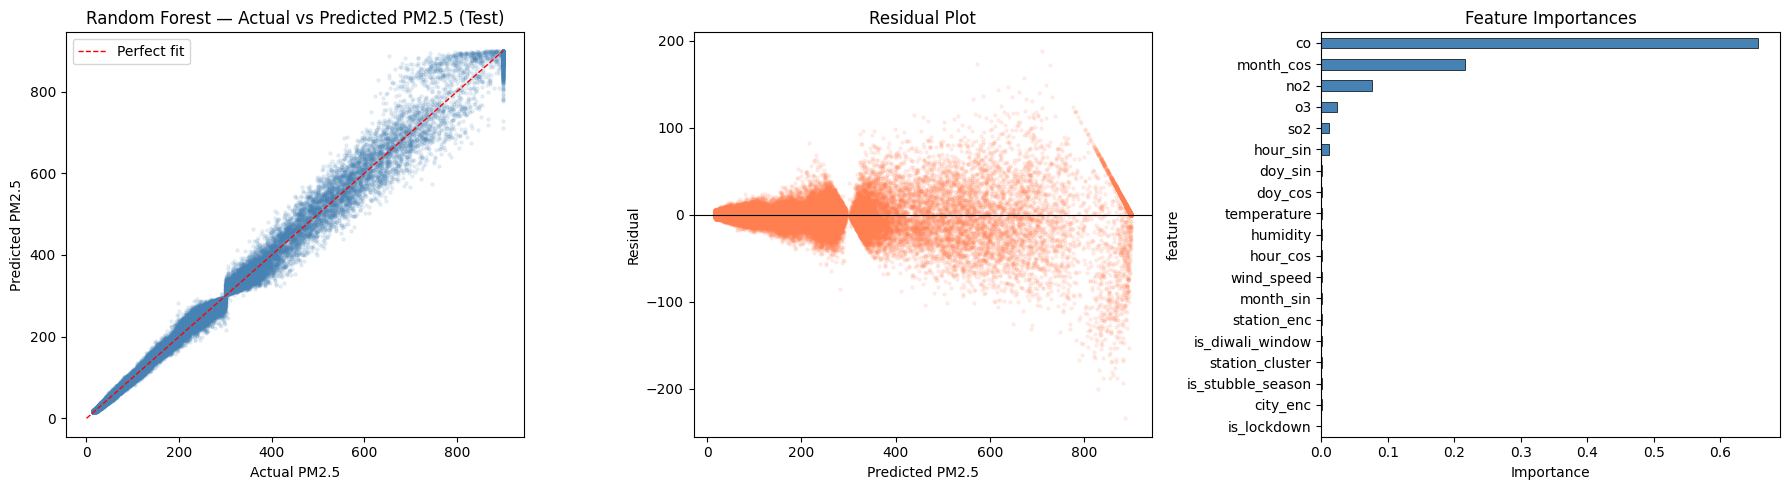

✓ Random Forest PM2.5 complete


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────
# TRAIN / TEST
# Uses your existing train and test datasets
# (NO lockdown removal)
# ─────────────────────────────────────────────────────────────
X_train_PM25 = train[FEATURES_PM25]
X_test_PM25  = test[FEATURES_PM25]

y_train_PM25 = train['pm25']
y_test_PM25  = test['pm25']


# ─────────────────────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────────────────────
rf_PM25 = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_PM25.fit(X_train_PM25, y_train_PM25)


# ─────────────────────────────────────────────────────────────
# PREDICT
# ─────────────────────────────────────────────────────────────
y_pred_train_PM25 = rf_PM25.predict(X_train_PM25)
y_pred_test_PM25  = rf_PM25.predict(X_test_PM25)


# ─────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────
print("=== RANDOM FOREST (PM2.5 Prediction) ===")

train_metrics_PM25 = regression_metrics(
    y_train_PM25,
    y_pred_train_PM25,
    "Train"
)

test_metrics_PM25 = regression_metrics(
    y_test_PM25,
    y_pred_test_PM25,
    "Test"
)

overfit_gap_PM25 = (
    train_metrics_PM25['R2']
    - test_metrics_PM25['R2']
)

print(f"\n  Overfitting gap : {overfit_gap_PM25:.4f}")
print(
    f"  {'⚠ Possible overfit' if overfit_gap_PM25 > 0.05 else '✓ No significant overfit'}"
)


# ─────────────────────────────────────────────────────────────
# TIME SERIES CROSS VALIDATION
# ─────────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=4)

cv_scores = cross_val_score(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    X_train_PM25,
    y_train_PM25,
    cv=tscv,
    scoring='r2'
)

print(f"\n  CV R² scores : {cv_scores.round(4)}")
print(f"  CV R² mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ─────────────────────────────────────────────────────────────
# FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────
feat_imp_PM25 = pd.DataFrame({
    'feature': FEATURES_PM25,
    'importance': rf_PM25.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Feature importances:")
print(feat_imp_PM25.to_string(index=False))


# ─────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Actual vs Predicted
axes[0].scatter(
    y_test_PM25,
    y_pred_test_PM25,
    alpha=0.1,
    s=5,
    color='steelblue'
)

max_pm25 = max(
    y_test_PM25.max(),
    y_pred_test_PM25.max()
)

axes[0].plot(
    [0, max_pm25],
    [0, max_pm25],
    'r--',
    linewidth=1,
    label='Perfect fit'
)

axes[0].set_xlabel('Actual PM2.5')
axes[0].set_ylabel('Predicted PM2.5')
axes[0].set_title('Random Forest — Actual vs Predicted PM2.5 (Test)')
axes[0].legend()


# Residual Plot
residuals_PM25 = y_test_PM25 - y_pred_test_PM25

axes[1].scatter(
    y_pred_test_PM25,
    residuals_PM25,
    alpha=0.1,
    s=5,
    color='coral'
)

axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')


# Feature Importance
feat_imp_PM25.plot(
    kind='barh',
    x='feature',
    y='importance',
    ax=axes[2],
    color='steelblue',
    edgecolor='black',
    linewidth=0.5
)

axes[2].invert_yaxis()
axes[2].set_title('Feature Importances')
axes[2].set_xlabel('Importance')
axes[2].legend().remove()


plt.tight_layout()
plt.savefig('rf_pm25_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Random Forest PM2.5 complete")

##XGBoost - Target PM2.5

=== XGBOOST (PM2.5) ===

  Train
    R²   : 0.9948
    RMSE : 14.44
    MAE  : 8.42
    MAPE : 5.35%

  Test
    R²   : 0.9913
    RMSE : 17.39
    MAE  : 9.36
    MAPE : 5.78%

  Overfitting gap : 0.0034
  ✓ No significant overfit

  CV R² scores : [0.9916 0.9915 0.9929 0.9921]
  CV R² mean   : 0.9920 ± 0.0006

  Feature importances:
          feature  importance
        month_cos        0.69
               co        0.15
              no2        0.07
              so2        0.04
         hour_sin        0.01
is_stubble_season        0.01
               o3        0.01
        month_sin        0.01
         hour_cos        0.00
          doy_sin        0.00
          doy_cos        0.00
 is_diwali_window        0.00
      temperature        0.00
         humidity        0.00
  station_cluster        0.00
       wind_speed        0.00
      station_enc        0.00
         city_enc        0.00
      is_lockdown        0.00


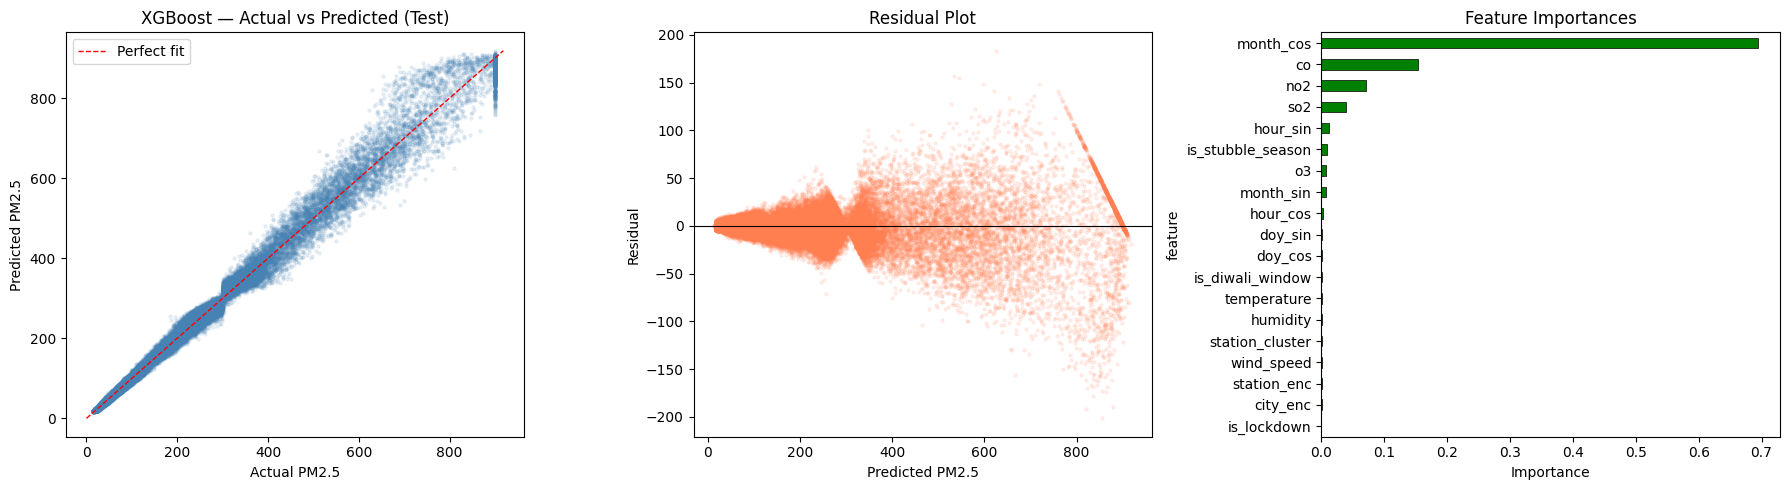

✓ XGBoost PM2.5 complete


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# ─────────────────────────────────────────────────────────────
# XGBOOST — PM2.5
# ─────────────────────────────────────────────────────────────
xgb_PM25 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_PM25.fit(X_train_PM25, y_train_PM25)

y_pred_train_xgb = xgb_PM25.predict(X_train_PM25)
y_pred_test_xgb  = xgb_PM25.predict(X_test_PM25)


# ─────────────────────────────────────────────────────────────
# Metrics
# ─────────────────────────────────────────────────────────────
print("=== XGBOOST (PM2.5) ===")

train_metrics_xgb = regression_metrics(
    y_train_PM25,
    y_pred_train_xgb,
    "Train"
)

test_metrics_xgb = regression_metrics(
    y_test_PM25,
    y_pred_test_xgb,
    "Test"
)

overfit_gap = train_metrics_xgb['R2'] - test_metrics_xgb['R2']

print(f"\n  Overfitting gap : {overfit_gap:.4f}")
print(f"  {'⚠ Possible overfit' if overfit_gap > 0.05 else '✓ No significant overfit'}")


# ─────────────────────────────────────────────────────────────
# Time-series cross validation
# ─────────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=4)

cv_scores = cross_val_score(
    XGBRegressor(
        n_estimators=100,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ),
    X_train_PM25,
    y_train_PM25,
    cv=tscv,
    scoring='r2'
)

print(f"\n  CV R² scores : {cv_scores.round(4)}")
print(f"  CV R² mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ─────────────────────────────────────────────────────────────
# Feature importance
# ─────────────────────────────────────────────────────────────
feat_imp_xgb = pd.DataFrame({
    'feature': FEATURES_PM25,
    'importance': xgb_PM25.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n  Feature importances:")
print(feat_imp_xgb.to_string(index=False))


# ─────────────────────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Actual vs Predicted
axes[0].scatter(
    y_test_PM25,
    y_pred_test_xgb,
    alpha=0.1,
    s=5,
    color='steelblue'
)

max_pm25 = max(
    y_test_PM25.max(),
    y_pred_test_xgb.max()
)

axes[0].plot(
    [0, max_pm25],
    [0, max_pm25],
    'r--',
    linewidth=1,
    label='Perfect fit'
)

axes[0].set_xlabel('Actual PM2.5')
axes[0].set_ylabel('Predicted PM2.5')
axes[0].set_title('XGBoost — Actual vs Predicted (Test)')
axes[0].legend()


# Residuals
residuals_xgb = y_test_PM25 - y_pred_test_xgb

axes[1].scatter(
    y_pred_test_xgb,
    residuals_xgb,
    alpha=0.1,
    s=5,
    color='coral'
)

axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')


# Feature Importance
feat_imp_xgb.plot(
    kind='barh',
    x='feature',
    y='importance',
    ax=axes[2],
    color='green',
    edgecolor='black',
    linewidth=0.5
)

axes[2].invert_yaxis()
axes[2].set_title('Feature Importances')
axes[2].set_xlabel('Importance')
axes[2].legend().remove()

plt.tight_layout()
plt.savefig('xgb_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ XGBoost PM2.5 complete")

##SVR with scaling - Target PM2.5

=== SVR (PM2.5) ===
⚠ Trained on 30K sample due to computational constraints

  Train
    R²   : 0.9920
    RMSE : 17.89
    MAE  : 9.93
    MAPE : 6.05%

  Test
    R²   : 0.9905
    RMSE : 18.20
    MAE  : 10.03
    MAPE : 6.43%

  Overfitting gap : 0.0015
  ✓ No significant overfit


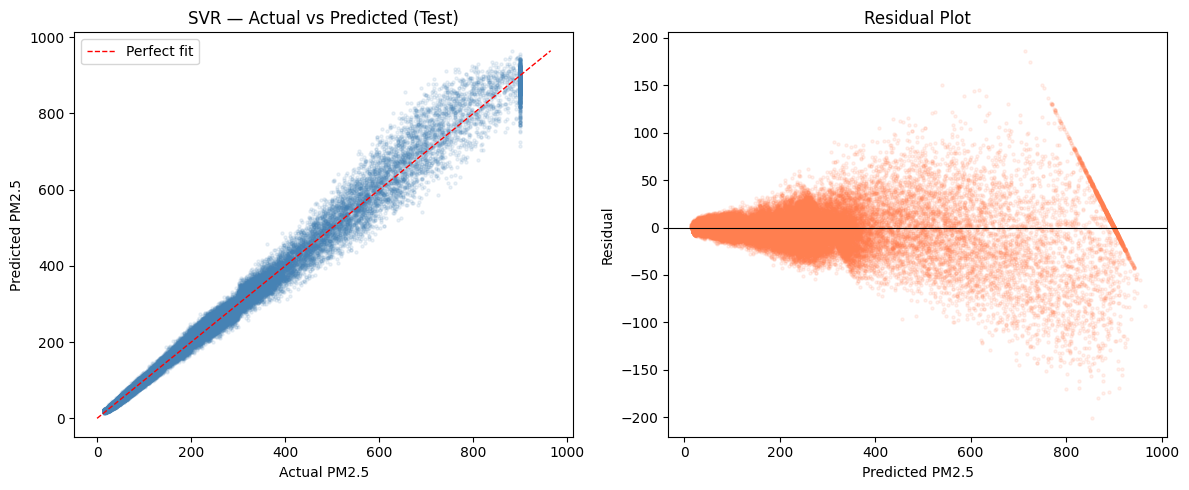

✓ SVR PM2.5 complete


In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.utils import resample


# Scale — mandatory for SVR
scaler_svr = StandardScaler()

X_train_svr = scaler_svr.fit_transform(X_train_PM25)
X_test_svr  = scaler_svr.transform(X_test_PM25)


# SVR on a sample first — full dataset is slow
# We train on 30K sample, test on full test set
X_sample, y_sample = resample(
    X_train_svr,
    y_train_PM25,
    n_samples=30000,
    random_state=42
)

svr_PM25 = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

svr_PM25.fit(X_sample, y_sample)


# Predictions
y_pred_train_svr = svr_PM25.predict(X_train_svr)
y_pred_test_svr  = svr_PM25.predict(X_test_svr)


# Metrics
print("=== SVR (PM2.5) ===")
print("⚠ Trained on 30K sample due to computational constraints")

train_metrics_svr = regression_metrics(
    y_train_PM25,
    y_pred_train_svr,
    "Train"
)

test_metrics_svr = regression_metrics(
    y_test_PM25,
    y_pred_test_svr,
    "Test"
)

overfit_gap = train_metrics_svr['R2'] - test_metrics_svr['R2']

print(f"\n  Overfitting gap : {overfit_gap:.4f}")
print(f"  {'⚠ Possible overfit' if overfit_gap > 0.05 else '✓ No significant overfit'}")


# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Actual vs Predicted
axes[0].scatter(
    y_test_PM25,
    y_pred_test_svr,
    alpha=0.1,
    s=5,
    color='steelblue'
)

max_pm25 = max(
    y_test_PM25.max(),
    y_pred_test_svr.max()
)

axes[0].plot(
    [0, max_pm25],
    [0, max_pm25],
    'r--',
    linewidth=1,
    label='Perfect fit'
)

axes[0].set_xlabel('Actual PM2.5')
axes[0].set_ylabel('Predicted PM2.5')
axes[0].set_title('SVR — Actual vs Predicted (Test)')
axes[0].legend()


# Residuals
residuals_svr = y_test_PM25 - y_pred_test_svr

axes[1].scatter(
    y_pred_test_svr,
    residuals_svr,
    alpha=0.1,
    s=5,
    color='coral'
)

axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')


plt.tight_layout()
plt.savefig(
    'svr_pm25.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✓ SVR PM2.5 complete")

##ANN - Target PM2.5

=== ANN (PM2.5) ===

  Train
    R²   : 0.9927
    RMSE : 17.14
    MAE  : 9.71
    MAPE : 5.99%

  Test
    R²   : 0.9915
    RMSE : 17.19
    MAE  : 9.73
    MAPE : 6.34%

  Overfitting gap : 0.0011
  ✓ No significant overfit

  CV R² scores : [0.9838 0.9844 0.9896 0.9921]
  CV R² mean   : 0.9875 ± 0.0035


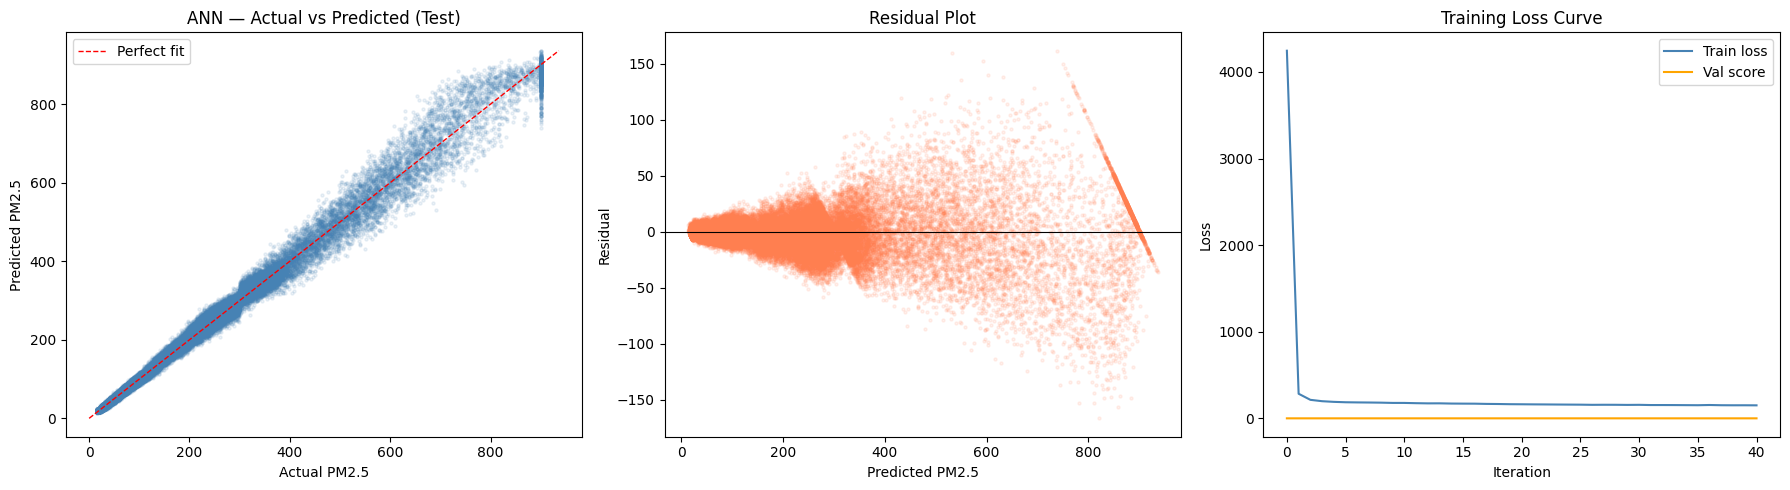

✓ ANN PM2.5 complete


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt

# Scale — mandatory for ANN
scaler_ann = StandardScaler()
X_train_ann = scaler_ann.fit_transform(X_train_PM25)
X_test_ann  = scaler_ann.transform(X_test_PM25)

# Define ANN model
ann_PM25 = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False
)

# Fit ANN
ann_PM25.fit(X_train_ann, y_train_PM25)

# Predictions
y_pred_train_ann = ann_PM25.predict(X_train_ann)
y_pred_test_ann  = ann_PM25.predict(X_test_ann)

# Metrics
print("=== ANN (PM2.5) ===")
train_metrics_ann = regression_metrics(y_train_PM25, y_pred_train_ann, "Train")
test_metrics_ann  = regression_metrics(y_test_PM25,  y_pred_test_ann,  "Test")

overfit_gap = train_metrics_ann['R2'] - test_metrics_ann['R2']
print(f"\n  Overfitting gap : {overfit_gap:.4f}")
print(f"  {'⚠ Possible overfit' if overfit_gap > 0.05 else '✓ No significant overfit'}")


# Cross-validation
tscv = TimeSeriesSplit(n_splits=4)
cv_scores = cross_val_score(
    MLPRegressor(hidden_layer_sizes=(128, 64, 32),
                 max_iter=200, random_state=42,
                 early_stopping=True),
    X_train_ann, y_train_PM25,
    cv=tscv, scoring='r2'
)
print(f"\n  CV R² scores : {cv_scores.round(4)}")
print(f"  CV R² mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test_PM25, y_pred_test_ann, alpha=0.1, s=5, color='steelblue')
max_pm25 = max(y_test_PM25.max(), y_pred_test_ann.max())
axes[0].plot([0, max_pm25], [0, max_pm25], 'r--', linewidth=1, label='Perfect fit')
axes[0].set_xlabel('Actual PM2.5')
axes[0].set_ylabel('Predicted PM2.5')
axes[0].set_title('ANN — Actual vs Predicted (Test)')
axes[0].legend()

# Residuals
residuals_ann = y_test_PM25 - y_pred_test_ann
axes[1].scatter(y_pred_test_ann, residuals_ann, alpha=0.1, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

# Training loss curve
axes[2].plot(ann_PM25.loss_curve_, color='steelblue', label='Train loss')
if hasattr(ann_PM25, 'validation_scores_'):
    axes[2].plot(ann_PM25.validation_scores_, color='orange', label='Val score')
axes[2].set_title('Training Loss Curve')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.tight_layout()
plt.savefig('ann_pm25.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ ANN PM2.5 complete")

Continuing Q1 with Random Forest as Selected Model for further Study

#SHAP for station clusters:
using PM2.5 RF


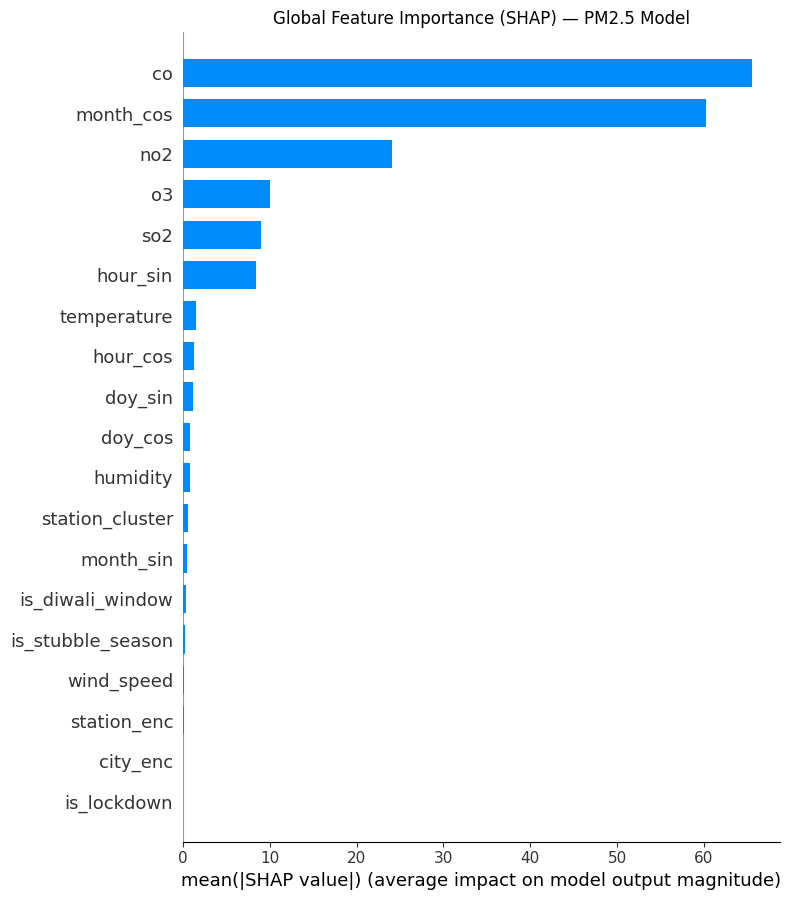

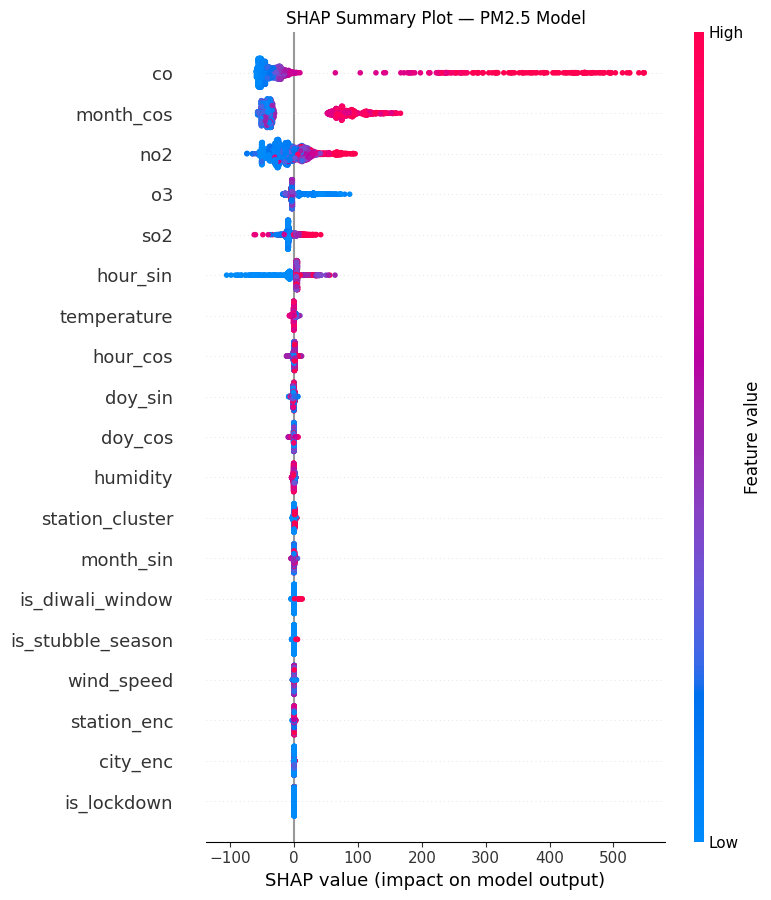


=== SHAP by Station Cluster (PM2.5) ===
                  no2  so2    co    o3  temperature  humidity  wind_speed  hour_sin  hour_cos  doy_sin  doy_cos  month_sin  month_cos  city_enc  station_enc  is_lockdown  is_diwali_window  is_stubble_season
station_cluster                                                                                                                                                                                               
0               24.95 9.25 61.54  9.46         1.33      0.76        0.17      7.90      1.44     1.04     0.80       0.41      60.08      0.07         0.11         0.00              0.38               0.19
1               23.20 8.12 66.69 12.14         1.68      0.84        0.19      8.45      1.17     1.44     0.84       0.59      62.80      0.04         0.18         0.00              0.29               0.22
2               23.47 9.05 69.78  9.44         1.55      0.80        0.18      9.05      1.27     1.11     0.90       0.43      58.

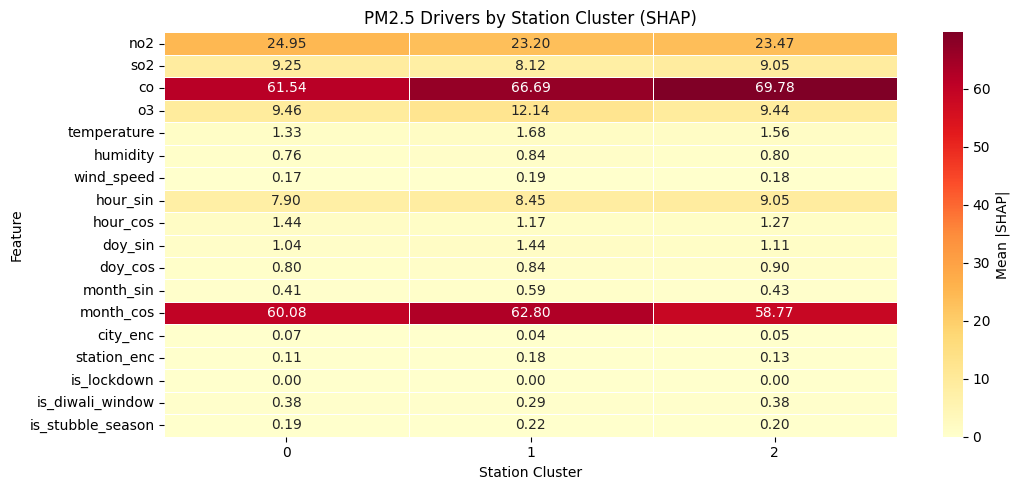


✓ SHAP analysis for PM2.5 complete


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ─────────────────────────────────────────────────────────────
# SAMPLE DATA FOR SHAP (to avoid heavy computation)
# ─────────────────────────────────────────────────────────────
X_shap = df[FEATURES_PM25].sample(2000, random_state=42)


# ─────────────────────────────────────────────────────────────
# CREATE EXPLAINER
# ─────────────────────────────────────────────────────────────
explainer = shap.TreeExplainer(rf_PM25)
shap_values = explainer.shap_values(X_shap)


# ─────────────────────────────────────────────────────────────
# GLOBAL SHAP SUMMARY (BAR PLOT)
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(8,5))
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP) — PM2.5 Model")
plt.tight_layout()
plt.savefig("shap_pm25_global.png", dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# DETAILED SHAP SUMMARY (DOT PLOT)
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(8,5))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("SHAP Summary Plot — PM2.5 Model")
plt.tight_layout()
plt.savefig("shap_pm25_summary.png", dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# CLUSTER-WISE SHAP ANALYSIS
# ─────────────────────────────────────────────────────────────
shap_abs = pd.DataFrame(
    np.abs(shap_values),
    columns=FEATURES_PM25,
    index=X_shap.index
)

shap_abs['station_cluster'] = df.loc[X_shap.index, 'station_cluster'].values

cluster_shap = shap_abs.groupby('station_cluster').mean()

print("\n=== SHAP by Station Cluster (PM2.5) ===")
print(cluster_shap.round(3).to_string())


# ─────────────────────────────────────────────────────────────
# HEATMAP (CLUSTER vs FEATURES)
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(11,5))
sns.heatmap(
    cluster_shap.T,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Mean |SHAP|'}
)

plt.title("PM2.5 Drivers by Station Cluster (SHAP)")
plt.xlabel("Station Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("shap_pm25_clusters.png", dpi=150, bbox_inches='tight')
plt.show()


print("\n✓ SHAP analysis for PM2.5 complete")

#Q2: How Much Can Policy Help? What is the quantifiable impact of intervention on air quality?

#Counterfactual Analysis
Using PM2.5 RF


In [ ]:
# ─────────────────────────────────────────────────────────────
# COUNTERFACTUAL 1: Remove Stubble Burning
# ─────────────────────────────────────────────────────────────
X_cf1 = X_test_PM25.copy()
X_cf1['is_stubble_season'] = 0


baseline = rf_PM25.predict(X_test_PM25)
cf1 = rf_PM25.predict(X_cf1)


print("\n=== POLICY SCENARIO: REMOVE STUBBLE BURNING ===")
print("Baseline PM2.5:", baseline.mean())
print("Counterfactual:", cf1.mean())
print("Impact:", baseline.mean() - cf1.mean())


# ─────────────────────────────────────────────────────────────
# COUNTERFACTUAL 2: Improve Dispersion (Wind Increase)
# ─────────────────────────────────────────────────────────────
X_cf2 = X_test_PM25.copy()
X_cf2['wind_speed'] = X_cf2['wind_speed'] * 1.2


cf2 = rf_PM25.predict(X_cf2)


print("\n=== POLICY SCENARIO: INCREASE WIND DISPERSION ===")
print("Baseline PM2.5:", baseline.mean())
print("Counterfactual:", cf2.mean())
print("Impact:", baseline.mean() - cf2.mean())


print("\n✓ PM2.5 POLICY SIMULATION COMPLETE")


=== POLICY SCENARIO: REMOVE STUBBLE BURNING ===
Baseline PM2.5: 180.46248359483425
Counterfactual: 180.10973151458288
Impact: 0.3527520802513777

=== POLICY SCENARIO: INCREASE WIND DISPERSION ===
Baseline PM2.5: 180.46248359483425
Counterfactual: 180.39109785939516
Impact: 0.07138573543909388

✓ PM2.5 POLICY SIMULATION COMPLETE


#Counterfactual Lockdown Impact
Using PM2.5 RF


In [ ]:
# ============================================================
# COUNTERFACTUAL LOCKDOWN IMPACT — PM2.5 MODEL
# ============================================================

import numpy as np

# Ensure datetime format
df['datetime'] = pd.to_datetime(df['datetime'])


# ─────────────────────────────────────────────────────────────
# LOCKDOWN PERIOD MASK
# ─────────────────────────────────────────────────────────────
LOCKDOWN_START = '2020-03-25'
LOCKDOWN_END   = '2020-06-08'

lock_mask = (
    (df['datetime'] >= LOCKDOWN_START) &
    (df['datetime'] <= LOCKDOWN_END)
)


# ─────────────────────────────────────────────────────────────
# BASELINE: ACTUAL LOCKDOWN CONDITIONS
# (using model-ready cleaned dataset with FEATURES_PM25)
# ─────────────────────────────────────────────────────────────
X_lock = df.loc[lock_mask, FEATURES_PM25].copy()

pred_actual = rf_PM25.predict(X_lock)


# ─────────────────────────────────────────────────────────────
# COUNTERFACTUAL: NO LOCKDOWN
# ─────────────────────────────────────────────────────────────
X_cf = X_lock.copy()
X_cf['is_lockdown'] = 0

pred_cf = rf_PM25.predict(X_cf)


# ─────────────────────────────────────────────────────────────
# IMPACT ESTIMATION
# ─────────────────────────────────────────────────────────────
impact = pred_actual.mean() - pred_cf.mean()


# ─────────────────────────────────────────────────────────────
# RESULTS
# ─────────────────────────────────────────────────────────────
print("\n=== COUNTERFACTUAL LOCKDOWN IMPACT (PM2.5 MODEL) ===")
print("Predicted PM2.5 (lockdown)   :", pred_actual.mean())
print("Predicted PM2.5 (no lockdown):", pred_cf.mean())
print("Estimated reduction           :", impact)

print("\n✓ PM2.5 COUNTERFACTUAL COMPLETE")


=== COUNTERFACTUAL LOCKDOWN IMPACT (PM2.5 MODEL) ===
Predicted PM2.5 (lockdown)   : 85.86062249454909
Predicted PM2.5 (no lockdown): 85.86062249454909
Estimated reduction           : 0.0

✓ PM2.5 COUNTERFACTUAL COMPLETE


#Observed Lockdown Impact

In [ ]:
# ============================================================
# OBSERVED LOCKDOWN IMPACT (DATA ONLY)
# ============================================================

import pandas as pd

df['datetime'] = pd.to_datetime(df['datetime'])


# ─────────────────────────────────────────────────────────────
# LOCKDOWN PERIOD
# ─────────────────────────────────────────────────────────────
LOCKDOWN_START = '2020-03-25'
LOCKDOWN_END   = '2020-06-08'

lock_mask = (
    (df['datetime'] >= LOCKDOWN_START) &
    (df['datetime'] <= LOCKDOWN_END)
)


# ------------------------------------------------------------
# Observed comparison
# ------------------------------------------------------------
lockdown_mean = df.loc[lock_mask, 'pm25'].mean()
normal_mean   = df.loc[~lock_mask, 'pm25'].mean()


print("\n=== OBSERVED LOCKDOWN IMPACT ===")
print("Lockdown PM2.5 mean :", lockdown_mean)
print("Normal PM2.5 mean   :", normal_mean)
print("Observed reduction   :", normal_mean - lockdown_mean)


print("\n✔ Observed analysis complete")


=== OBSERVED LOCKDOWN IMPACT ===
Lockdown PM2.5 mean : 86.47585507246377
Normal PM2.5 mean   : 186.85484073031978
Observed reduction   : 100.378985657856

✔ Observed analysis complete


#Observed impact of Lockdown (YEAR-WISE)

In [ ]:
# ============================================================
# YEAR-WISE LOCKDOWN WINDOW COMPARISON (DATA ONLY)
# ============================================================

import pandas as pd

df['datetime'] = pd.to_datetime(df['datetime'])


# ─────────────────────────────────────────────────────────────
# LOCKDOWN WINDOW
# ─────────────────────────────────────────────────────────────
LOCKDOWN_START = '2020-03-25'
LOCKDOWN_END   = '2020-06-08'


# Extract same window for ALL years
df_window = df[
    (df['datetime'].dt.month >= 3) &
    (df['datetime'].dt.month <= 6)
].copy()


# Keep only exact lockdown-day range alignment
df_window = df_window[
    (df_window['datetime'].dt.day >= 25) |
    (df_window['datetime'].dt.month > 3)
]

df_window = df_window[
    (df_window['datetime'].dt.month < 6) |
    (df_window['datetime'].dt.day <= 8)
]


# Add year column
df_window['year'] = df_window['datetime'].dt.year


# ─────────────────────────────────────────────────────────────
# YEARLY MEANS
# ─────────────────────────────────────────────────────────────
yearly_pm25 = df_window.groupby('year')['pm25'].mean()


# ─────────────────────────────────────────────────────────────
# RESULTS
# ─────────────────────────────────────────────────────────────
print("\n=== YEAR-WISE LOCKDOWN WINDOW COMPARISON (PM2.5) ===")

for year, val in yearly_pm25.items():
    print(f"{year} PM2.5 mean: {val:.2f}")


print("\nDifferences vs 2020:")
base = yearly_pm25.loc[2020]

for year, val in yearly_pm25.items():
    print(f"{year} vs 2020: {val - base:.2f}")


print("\n✓ YEAR-WISE COMPARISON COMPLETE")


=== YEAR-WISE LOCKDOWN WINDOW COMPARISON (PM2.5) ===
2020 PM2.5 mean: 86.16
2021 PM2.5 mean: 84.91
2022 PM2.5 mean: 83.72
2023 PM2.5 mean: 82.37
2024 PM2.5 mean: 81.28
2025 PM2.5 mean: 79.81

Differences vs 2020:
2020 vs 2020: 0.00
2021 vs 2020: -1.25
2022 vs 2020: -2.44
2023 vs 2020: -3.79
2024 vs 2020: -4.87
2025 vs 2020: -6.35

✓ YEAR-WISE COMPARISON COMPLETE


# Q3: What proportion of AQI variation is driven by meteorology (wind, temperature, humidity) vs human activity (vehicles, industry)?

##Dataset- Weather only

In [ ]:
# ─────────────────────────────────────────────────────────────
# TARGET
# ─────────────────────────────────────────────────────────────
y_train_aqi = train['aqi']
y_test_aqi  = test['aqi']


# ─────────────────────────────────────────────────────────────
# FEATURE SET — WITH VISIBILITY
# ─────────────────────────────────────────────────────────────
features_weather = [
    'temperature', 'humidity', 'wind_speed', 'visibility',
    'city_enc', 'station_cluster'
]


# ─────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────
X_train_weather = train[features_weather]
X_test_weather  = test[features_weather]


print("✓ WEATHER (WITH VISIBILITY) SPLIT COMPLETE")
print(f"  Features : {len(features_weather)}")
print(f"  Train shape : {X_train_weather.shape}")
print(f"  Test shape  : {X_test_weather.shape}")

✓ WEATHER (WITH VISIBILITY) SPLIT COMPLETE
  Features : 6
  Train shape : (127512, 6)
  Test shape  : (67252, 6)


##Random Forest- weather based

=== RANDOM FOREST (Weather — With Visibility) ===

  Train
    R²   : 0.9776
    RMSE : 26.05
    MAE  : 18.09
    MAPE : 11.98%

  Test
    R²   : 0.9603
    RMSE : 34.24
    MAE  : 24.11
    MAPE : 16.88%

  Overfitting gap : 0.0173
  ✓ No significant overfit

  CV R² scores : [0.9577 0.9593 0.9591 0.9585]
  CV R² mean   : 0.9587 ± 0.0006

  Feature importances:
        feature  importance
     visibility        0.88
       humidity        0.07
    temperature        0.03
     wind_speed        0.02
station_cluster        0.00
       city_enc        0.00


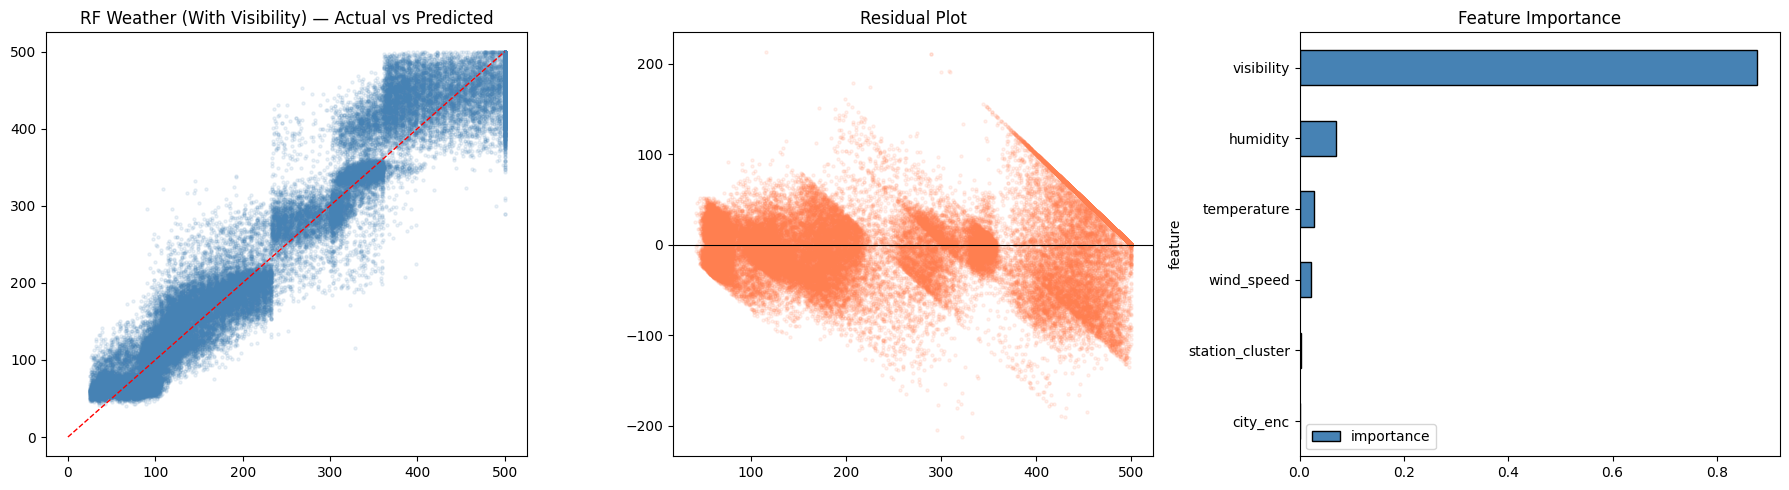

✓ RF Weather (With Visibility) complete


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt


rf_weather = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_weather.fit(X_train_weather, y_train_aqi)


y_pred_train_weather = rf_weather.predict(X_train_weather)
y_pred_test_weather  = rf_weather.predict(X_test_weather)


print("=== RANDOM FOREST (Weather — With Visibility) ===")

train_metrics_weather = regression_metrics(y_train_aqi, y_pred_train_weather, "Train")
test_metrics_weather  = regression_metrics(y_test_aqi,  y_pred_test_weather,  "Test")

overfit_gap_weather = train_metrics_weather['R2'] - test_metrics_weather['R2']

print(f"\n  Overfitting gap : {overfit_gap_weather:.4f}")
print(f"  {'⚠ Possible overfit' if overfit_gap_weather > 0.05 else '✓ No significant overfit'}")


tscv = TimeSeriesSplit(n_splits=4)

cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_weather,
    y_train_aqi,
    cv=tscv,
    scoring='r2'
)

print(f"\n  CV R² scores : {cv_scores.round(4)}")
print(f"  CV R² mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


feat_imp_weather = pd.DataFrame({
    'feature': features_weather,
    'importance': rf_weather.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Feature importances:")
print(feat_imp_weather.to_string(index=False))


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].scatter(y_test_aqi, y_pred_test_weather, alpha=0.1, s=5, color='steelblue')
axes[0].plot([0, 500], [0, 500], 'r--', linewidth=1)
axes[0].set_title('RF Weather (With Visibility) — Actual vs Predicted')


residuals = y_test_aqi - y_pred_test_weather
axes[1].scatter(y_pred_test_weather, residuals, alpha=0.1, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residual Plot')


feat_imp_weather.plot(
    kind='barh',
    x='feature',
    y='importance',
    ax=axes[2],
    color='steelblue',
    edgecolor='black'
)

axes[2].invert_yaxis()
axes[2].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('rf_weather_visibility.png', dpi=150)
plt.show()

print("✓ RF Weather (With Visibility) complete")

Removing visibility to avoid target leakage since it is strongly driven by AQI (poor AQI → low visibility).

##Dataset- weather without visibility

In [ ]:
# ─────────────────────────────────────────────────────────────
# TARGET
# ─────────────────────────────────────────────────────────────
y_train_aqi = train['aqi']
y_test_aqi  = test['aqi']


# ─────────────────────────────────────────────────────────────
# FEATURE SET — WITHOUT VISIBILITY
# ─────────────────────────────────────────────────────────────
features_weather_noVisibility = [
    'temperature', 'humidity', 'wind_speed',
    'city_enc', 'station_cluster'
]


# ─────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────
X_train_weather_noVis = train[features_weather_noVisibility]
X_test_weather_noVis  = test[features_weather_noVisibility]


print("✓ WEATHER (NO VISIBILITY) SPLIT COMPLETE")
print(f"  Features : {len(features_weather_noVisibility)}")
print(f"  Train shape : {X_train_weather_noVis.shape}")
print(f"  Test shape  : {X_test_weather_noVis.shape}")

✓ WEATHER (NO VISIBILITY) SPLIT COMPLETE
  Features : 5
  Train shape : (127512, 5)
  Test shape  : (67252, 5)


##Random Forest- Weather Based Without Visibility

=== RANDOM FOREST (Weather — No Visibility) ===

  Train
    R²   : 0.9376
    RMSE : 43.53
    MAE  : 30.70
    MAPE : 17.77%

  Test
    R²   : 0.8892
    RMSE : 57.21
    MAE  : 40.10
    MAPE : 24.53%

  Overfitting gap : 0.0484
  ✓ No significant overfit

  Feature importances (No Visibility):
        feature  importance
    temperature        0.64
       humidity        0.24
     wind_speed        0.11
station_cluster        0.01
       city_enc        0.00


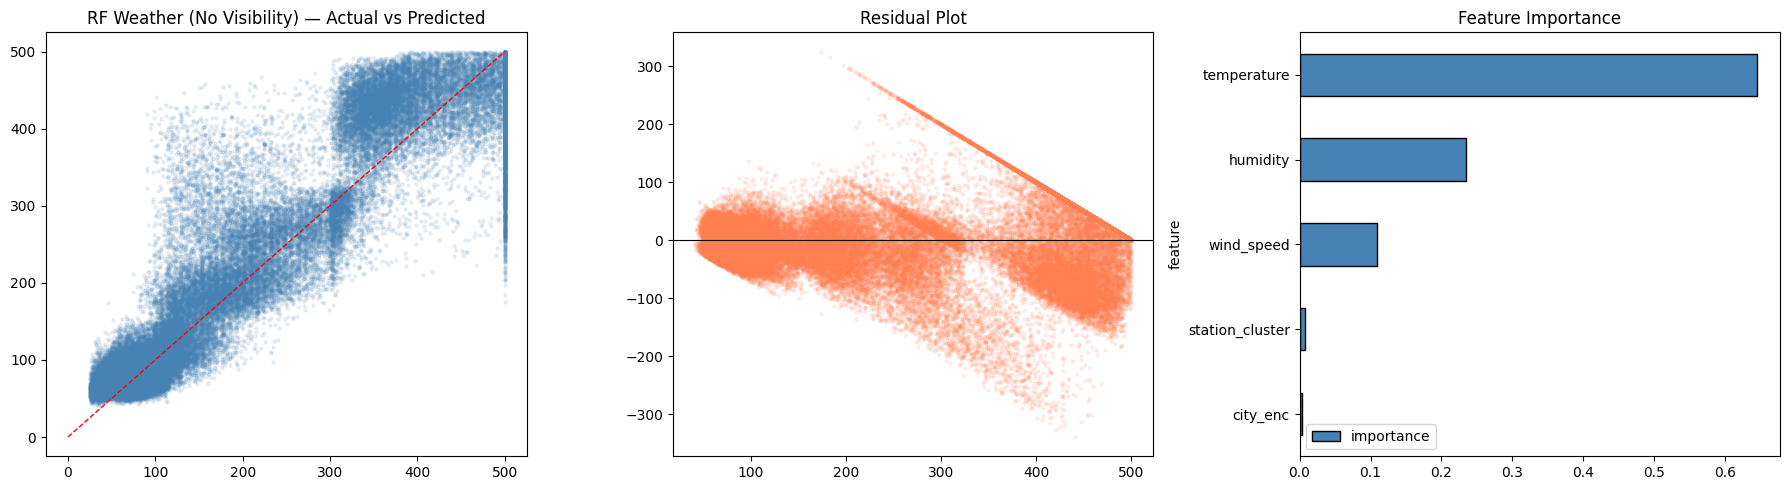

✓ RF Weather (No Visibility) complete


In [ ]:
rf_weather_noVis = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_weather_noVis.fit(X_train_weather_noVis, y_train_aqi)


y_pred_train_noVis = rf_weather_noVis.predict(X_train_weather_noVis)
y_pred_test_noVis  = rf_weather_noVis.predict(X_test_weather_noVis)


print("=== RANDOM FOREST (Weather — No Visibility) ===")

train_metrics_noVis = regression_metrics(y_train_aqi, y_pred_train_noVis, "Train")
test_metrics_noVis  = regression_metrics(y_test_aqi,  y_pred_test_noVis,  "Test")

overfit_gap_noVis = train_metrics_noVis['R2'] - test_metrics_noVis['R2']

print(f"\n  Overfitting gap : {overfit_gap_noVis:.4f}")
print(f"  {'⚠ Possible overfit' if overfit_gap_noVis > 0.05 else '✓ No significant overfit'}")


feat_imp_noVis = pd.DataFrame({
    'feature': features_weather_noVisibility,
    'importance': rf_weather_noVis.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Feature importances (No Visibility):")
print(feat_imp_noVis.to_string(index=False))


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].scatter(y_test_aqi, y_pred_test_noVis, alpha=0.1, s=5, color='steelblue')
axes[0].plot([0, 500], [0, 500], 'r--', linewidth=1)
axes[0].set_title('RF Weather (No Visibility) — Actual vs Predicted')


residuals_noVis = y_test_aqi - y_pred_test_noVis
axes[1].scatter(y_pred_test_noVis, residuals_noVis, alpha=0.1, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residual Plot')


feat_imp_noVis.plot(
    kind='barh',
    x='feature',
    y='importance',
    ax=axes[2],
    color='steelblue',
    edgecolor='black'
)

axes[2].invert_yaxis()
axes[2].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('rf_weather_no_visibility.png', dpi=150)
plt.show()

print("✓ RF Weather (No Visibility) complete")

##XGBoost Weather based without Visibility


✓ WEATHER (NO VISIBILITY) SPLIT COMPLETE
  Features : 5
  Train shape : (127512, 5)
  Test shape  : (67252, 5)

=== XGBOOST (Weather — No Visibility) ===

  Train
    R²   : 0.9079
    RMSE : 52.88
    MAE  : 38.52
    MAPE : 22.41%

  Test
    R²   : 0.8909
    RMSE : 56.77
    MAE  : 40.72
    MAPE : 24.86%

  Overfitting gap : 0.0170
  ✓ No significant overfit

  CV R² scores : [0.8956 0.9002 0.9008 0.897 ]
  CV R² mean   : 0.8984 ± 0.0022

  Feature importances (No Visibility):
        feature  importance
    temperature        0.37
       humidity        0.35
     wind_speed        0.26
station_cluster        0.02
       city_enc        0.00


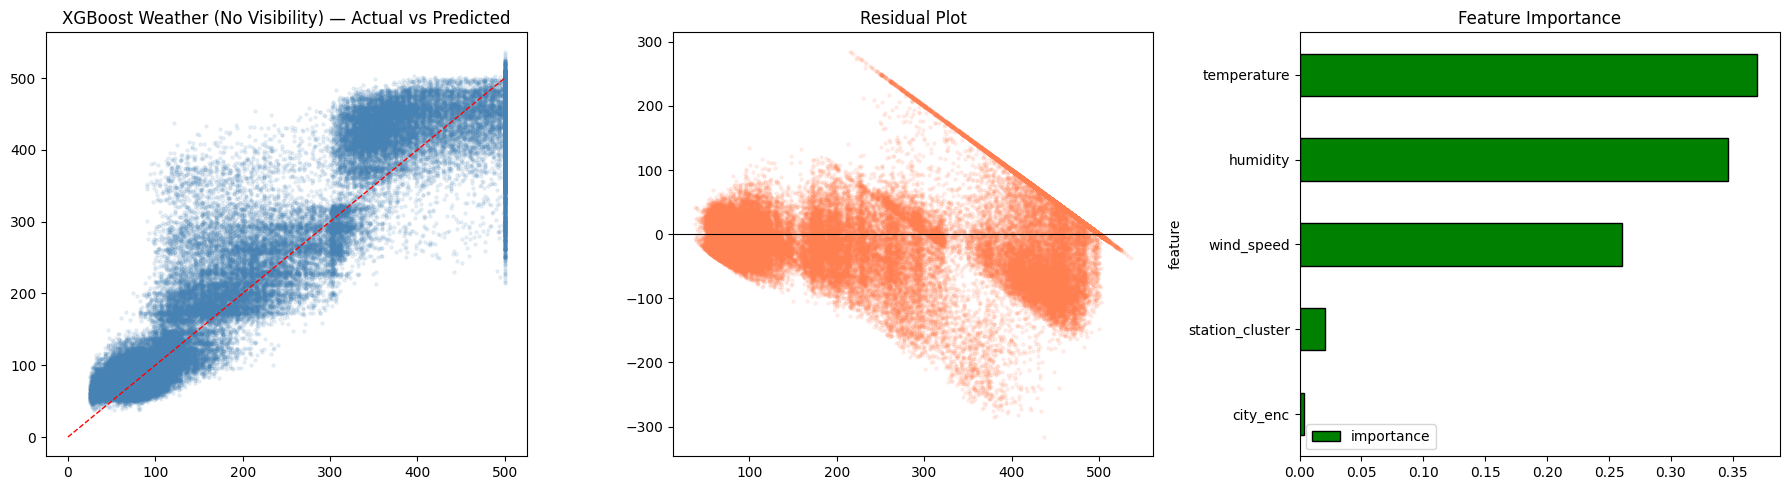

✓ XGBoost Weather (No Visibility) complete


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt


# ─────────────────────────────────────────────────────────────
# TARGET
# ─────────────────────────────────────────────────────────────
y_train_aqi = train['aqi']
y_test_aqi  = test['aqi']


# ─────────────────────────────────────────────────────────────
# FEATURE SET — WITHOUT VISIBILITY
# ─────────────────────────────────────────────────────────────
features_weather_noVisibility = [
    'temperature', 'humidity', 'wind_speed',
    'city_enc', 'station_cluster'
]


# ─────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────
X_train_weather_noVis = train[features_weather_noVisibility]
X_test_weather_noVis  = test[features_weather_noVisibility]


print("✓ WEATHER (NO VISIBILITY) SPLIT COMPLETE")
print(f"  Features : {len(features_weather_noVisibility)}")
print(f"  Train shape : {X_train_weather_noVis.shape}")
print(f"  Test shape  : {X_test_weather_noVis.shape}")


# ─────────────────────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────────────────────
xgb_weather_noVis = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_weather_noVis.fit(X_train_weather_noVis, y_train_aqi)


# ─────────────────────────────────────────────────────────────
# PREDICT
# ─────────────────────────────────────────────────────────────
y_pred_train_noVis = xgb_weather_noVis.predict(X_train_weather_noVis)
y_pred_test_noVis  = xgb_weather_noVis.predict(X_test_weather_noVis)


# ─────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────
print("\n=== XGBOOST (Weather — No Visibility) ===")

train_metrics_noVis = regression_metrics(y_train_aqi, y_pred_train_noVis, "Train")
test_metrics_noVis  = regression_metrics(y_test_aqi,  y_pred_test_noVis,  "Test")

overfit_gap_noVis = train_metrics_noVis['R2'] - test_metrics_noVis['R2']

print(f"\n  Overfitting gap : {overfit_gap_noVis:.4f}")
print(f"  {'⚠ Possible overfit' if overfit_gap_noVis > 0.05 else '✓ No significant overfit'}")


# ─────────────────────────────────────────────────────────────
# CROSS VALIDATION
# ─────────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=4)

cv_scores = cross_val_score(
    XGBRegressor(
        n_estimators=100,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ),
    X_train_weather_noVis,
    y_train_aqi,
    cv=tscv,
    scoring='r2'
)

print(f"\n  CV R² scores : {cv_scores.round(4)}")
print(f"  CV R² mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ─────────────────────────────────────────────────────────────
# FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────
feat_imp_noVis = pd.DataFrame({
    'feature': features_weather_noVisibility,
    'importance': xgb_weather_noVis.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Feature importances (No Visibility):")
print(feat_imp_noVis.to_string(index=False))


# ─────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Actual vs Predicted
axes[0].scatter(
    y_test_aqi,
    y_pred_test_noVis,
    alpha=0.1,
    s=5,
    color='steelblue'
)

axes[0].plot([0, 500], [0, 500], 'r--', linewidth=1)
axes[0].set_title('XGBoost Weather (No Visibility) — Actual vs Predicted')


# Residual Plot
residuals_noVis = y_test_aqi - y_pred_test_noVis

axes[1].scatter(
    y_pred_test_noVis,
    residuals_noVis,
    alpha=0.1,
    s=5,
    color='coral'
)

axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residual Plot')


# Feature Importance
feat_imp_noVis.plot(
    kind='barh',
    x='feature',
    y='importance',
    ax=axes[2],
    color='green',
    edgecolor='black'
)

axes[2].invert_yaxis()
axes[2].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('xgb_weather_no_visibility.png', dpi=150)
plt.show()

print("✓ XGBoost Weather (No Visibility) complete")

#SHAP on XGBoost (Weather Based without Visibility)

[17:30:14] Building SHAP explainer...
Explainer time: 0.6156108379364014
[17:30:14] Sampling data...
Sampling time: 0.006741762161254883
Shape: (500, 5)
[17:30:14] Computing SHAP values...
SHAP time: 10.127325057983398
[17:30:24] Creating SHAP summary plot...


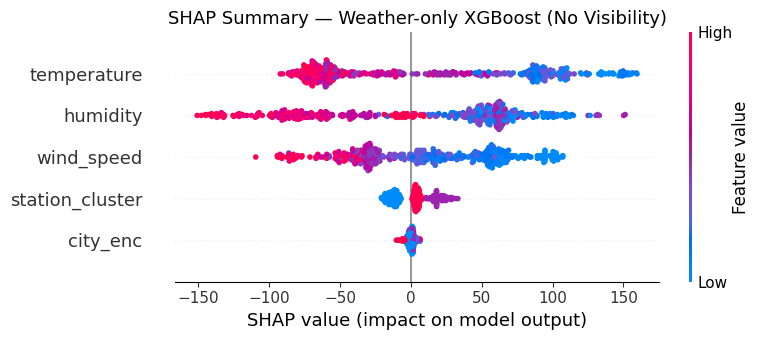

[17:30:25] Computing mean SHAP importance...

=== Mean SHAP Importance ===
        feature  mean_shap
    temperature      70.22
       humidity      64.44
     wind_speed      44.47
station_cluster      11.30
       city_enc       1.74


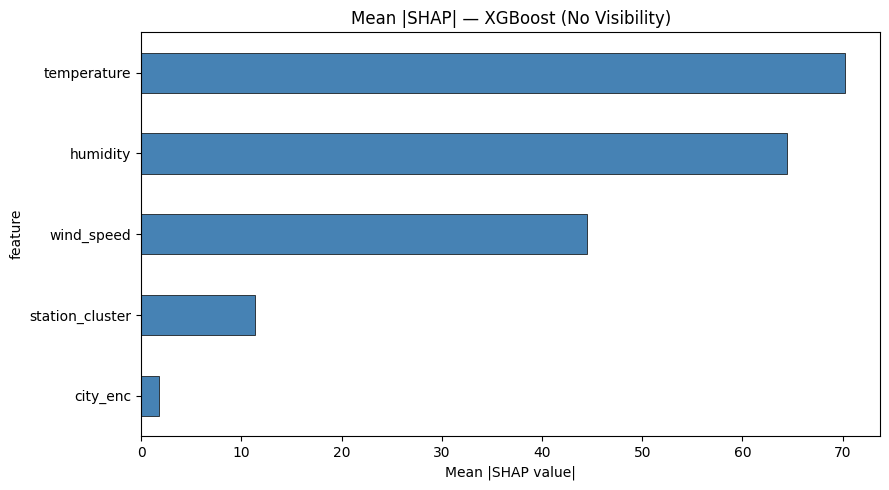

[17:30:25] Running SHAP variance decomposition...

=== SHAP Variance Decomposition ===
  Weather (current)         : 179.14  (93.2%)
  Spatial                   : 13.04  (6.8%)


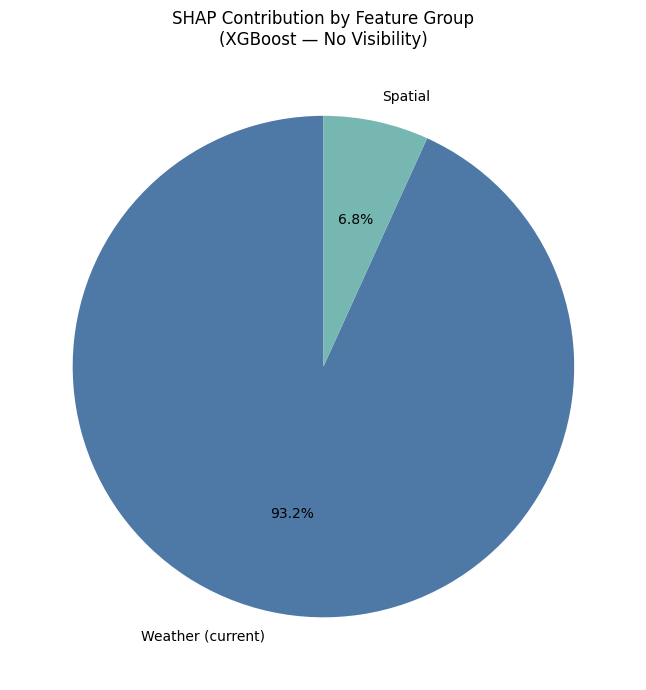


✓ SHAP analysis complete (XGBoost)


In [ ]:
# ============================================================
# SHAP — WEATHER-ONLY XGBOOST (NO VISIBILITY)
# ============================================================

import shap
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")


# ─────────────────────────────────────────────────────────────
# Build explainer (XGBOOST VERSION)
# ─────────────────────────────────────────────────────────────
log("Building SHAP explainer...")

start = time.time()

explainer_N = shap.Explainer(
    xgb_weather_noVis,   # ✅ XGBoost model
    X_train_weather_noVis  # background data (important)
)

print("Explainer time:", time.time() - start)


# ─────────────────────────────────────────────────────────────
# Sample test data
# ─────────────────────────────────────────────────────────────
log("Sampling data...")

start = time.time()

sample_size = min(500, len(X_test_weather_noVis))

sample_idx_N = np.random.choice(
    len(X_test_weather_noVis),
    size=sample_size,
    replace=False
)

X_shap_N = X_test_weather_noVis.iloc[sample_idx_N]

print("Sampling time:", time.time() - start)
print("Shape:", X_shap_N.shape)


# ─────────────────────────────────────────────────────────────
# Compute SHAP values
# ─────────────────────────────────────────────────────────────
log("Computing SHAP values...")

start = time.time()

shap_values_N = explainer_N(X_shap_N)

print("SHAP time:", time.time() - start)


# ─────────────────────────────────────────────────────────────
# SHAP Summary Plot
# ─────────────────────────────────────────────────────────────
log("Creating SHAP summary plot...")

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_N.values,
    X_shap_N,
    show=False
)

plt.title(
    "SHAP Summary — Weather-only XGBoost (No Visibility)",
    fontsize=13
)

plt.tight_layout()
plt.savefig(
    'shap_summary_xgb_no_visibility.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


# ─────────────────────────────────────────────────────────────
# Mean SHAP Importance
# ─────────────────────────────────────────────────────────────
log("Computing mean SHAP importance...")

mean_shap_N = pd.DataFrame({
    'feature': X_shap_N.columns,
    'mean_shap': np.abs(shap_values_N.values).mean(axis=0)
}).sort_values(
    'mean_shap',
    ascending=False
)

print("\n=== Mean SHAP Importance ===")
print(mean_shap_N.to_string(index=False))


fig, ax = plt.subplots(figsize=(9, 5))

mean_shap_N.plot(
    kind='barh',
    x='feature',
    y='mean_shap',
    ax=ax,
    color='steelblue',
    edgecolor='black',
    linewidth=0.5
)

ax.invert_yaxis()
ax.set_title('Mean |SHAP| — XGBoost (No Visibility)')
ax.set_xlabel('Mean |SHAP value|')
ax.legend().remove()

plt.tight_layout()
plt.savefig(
    'shap_bar_xgb_no_visibility.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


# ─────────────────────────────────────────────────────────────
# SHAP Variance Decomposition
# ─────────────────────────────────────────────────────────────
log("Running SHAP variance decomposition...")

feature_groups_N = {
    'Weather (current)': [
        'temperature',
        'humidity',
        'wind_speed'
    ],

    'Spatial': [
        'city_enc',
        'station_cluster'
    ]
}


shap_variance_N = {}

for group, feats in feature_groups_N.items():

    idx = [
        X_shap_N.columns.get_loc(f)
        for f in feats
        if f in X_shap_N.columns
    ]

    shap_variance_N[group] = (
        np.abs(shap_values_N.values[:, idx])
        .sum(axis=1)
        .mean()
    )


total_N = sum(shap_variance_N.values())

print("\n=== SHAP Variance Decomposition ===")

for group, val in shap_variance_N.items():
    print(
        f"  {group:<25} : "
        f"{val:.2f}  ({val/total_N*100:.1f}%)"
    )


# ─────────────────────────────────────────────────────────────
# Pie Chart
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    shap_variance_N.values(),
    labels=shap_variance_N.keys(),
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4e79a7', '#76b7b2']
)

ax.set_title(
    'SHAP Contribution by Feature Group\n(XGBoost — No Visibility)',
    fontsize=12
)

plt.tight_layout()
plt.savefig(
    'shap_pie_xgb_no_visibility.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


print("\n✓ SHAP analysis complete (XGBoost)")

#SHAP on Random Forest (Weather Based without Visibility)

[17:30:26] Building SHAP explainer...
Explainer time: 1.3065416812896729
[17:30:27] Sampling data...
Sampling time: 0.006993532180786133
Shape: (500, 5)
[17:30:27] Computing SHAP values...
SHAP time: 267.26095724105835
[17:34:54] Creating SHAP summary plot...


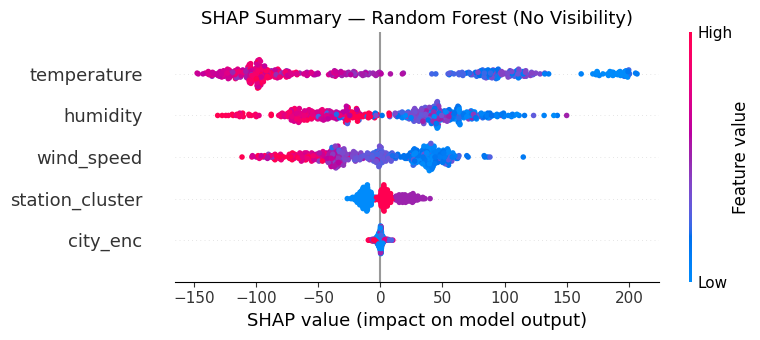

[17:34:55] Computing mean SHAP importance...

=== Mean SHAP Importance (RF) ===
        feature  mean_shap
    temperature      98.07
       humidity      51.83
     wind_speed      39.32
station_cluster      11.92
       city_enc       1.55


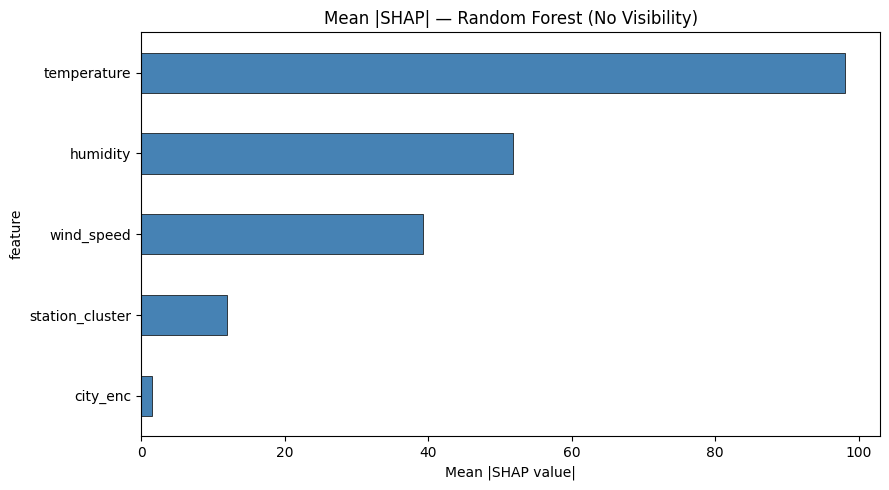

[17:34:56] Running SHAP variance decomposition...

=== SHAP Variance Decomposition (RF) ===
  Weather (current)         : 189.21  (93.4%)
  Spatial                   : 13.47  (6.6%)


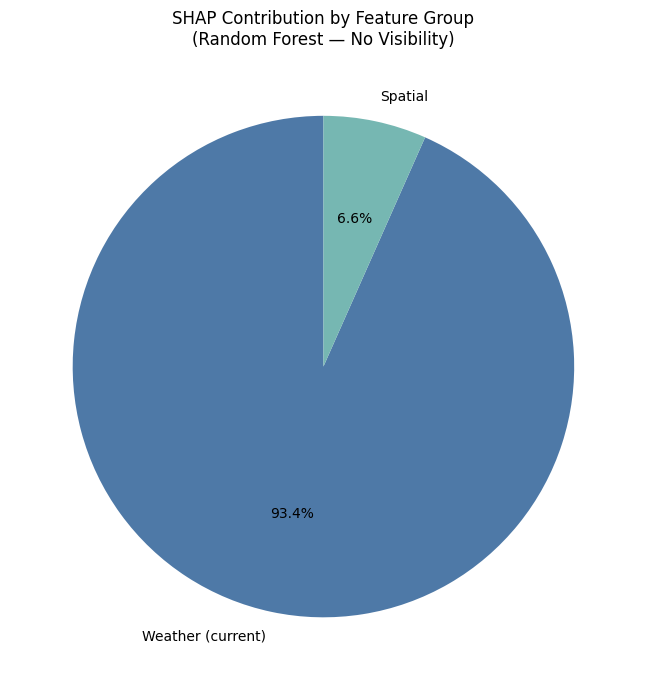


✓ SHAP analysis complete (Random Forest)


In [ ]:
# ============================================================
# SHAP — WEATHER-ONLY RANDOM FOREST (NO VISIBILITY)
# ============================================================

import shap
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")


# ─────────────────────────────────────────────────────────────
# Build explainer (RANDOM FOREST VERSION)
# ─────────────────────────────────────────────────────────────
log("Building SHAP explainer...")

start = time.time()

explainer_N = shap.TreeExplainer(
    rf_weather_noVis   # ✅ your trained RF model
)

print("Explainer time:", time.time() - start)


# ─────────────────────────────────────────────────────────────
# Sample test data
# ─────────────────────────────────────────────────────────────
log("Sampling data...")

start = time.time()

sample_size = min(500, len(X_test_weather_noVis))

sample_idx_N = np.random.choice(
    len(X_test_weather_noVis),
    size=sample_size,
    replace=False
)

X_shap_N = X_test_weather_noVis.iloc[sample_idx_N]

print("Sampling time:", time.time() - start)
print("Shape:", X_shap_N.shape)


# ─────────────────────────────────────────────────────────────
# Compute SHAP values
# ─────────────────────────────────────────────────────────────
log("Computing SHAP values...")

start = time.time()

shap_values_N = explainer_N.shap_values(
    X_shap_N,
    check_additivity=False
)

print("SHAP time:", time.time() - start)


# ─────────────────────────────────────────────────────────────
# SHAP Summary Plot
# ─────────────────────────────────────────────────────────────
log("Creating SHAP summary plot...")

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_N,
    X_shap_N,
    show=False
)

plt.title(
    "SHAP Summary — Random Forest (No Visibility)",
    fontsize=13
)

plt.tight_layout()
plt.savefig(
    'shap_summary_rf_no_visibility.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


# ─────────────────────────────────────────────────────────────
# Mean SHAP Importance
# ─────────────────────────────────────────────────────────────
log("Computing mean SHAP importance...")

mean_shap_N = pd.DataFrame({
    'feature': X_shap_N.columns,
    'mean_shap': np.abs(shap_values_N).mean(axis=0)
}).sort_values(
    'mean_shap',
    ascending=False
)

print("\n=== Mean SHAP Importance (RF) ===")
print(mean_shap_N.to_string(index=False))


fig, ax = plt.subplots(figsize=(9, 5))

mean_shap_N.plot(
    kind='barh',
    x='feature',
    y='mean_shap',
    ax=ax,
    color='steelblue',
    edgecolor='black',
    linewidth=0.5
)

ax.invert_yaxis()
ax.set_title('Mean |SHAP| — Random Forest (No Visibility)')
ax.set_xlabel('Mean |SHAP value|')
ax.legend().remove()

plt.tight_layout()
plt.savefig(
    'shap_bar_rf_no_visibility.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


# ─────────────────────────────────────────────────────────────
# SHAP Variance Decomposition
# ─────────────────────────────────────────────────────────────
log("Running SHAP variance decomposition...")

feature_groups_N = {
    'Weather (current)': [
        'temperature',
        'humidity',
        'wind_speed'
    ],

    'Spatial': [
        'city_enc',
        'station_cluster'
    ]
}


shap_variance_N = {}

for group, feats in feature_groups_N.items():

    idx = [
        X_shap_N.columns.get_loc(f)
        for f in feats
        if f in X_shap_N.columns
    ]

    shap_variance_N[group] = (
        np.abs(shap_values_N[:, idx])
        .sum(axis=1)
        .mean()
    )


total_N = sum(shap_variance_N.values())

print("\n=== SHAP Variance Decomposition (RF) ===")

for group, val in shap_variance_N.items():
    print(
        f"  {group:<25} : "
        f"{val:.2f}  ({val/total_N*100:.1f}%)"
    )


# ─────────────────────────────────────────────────────────────
# PIE CHART
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    shap_variance_N.values(),
    labels=shap_variance_N.keys(),
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4e79a7', '#76b7b2']
)

ax.set_title(
    'SHAP Contribution by Feature Group\n(Random Forest — No Visibility)',
    fontsize=12
)

plt.tight_layout()
plt.savefig(
    'shap_pie_rf_no_visibility.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


print("\n✓ SHAP analysis complete (Random Forest)")

#SHAP (FULL MODEL- XGBoost Target PM2.5)

[17:34:56] Building SHAP explainer...
[17:34:57] Sampling test data...
[17:34:57] Computing SHAP values...
[17:35:06] Creating SHAP summary plot...


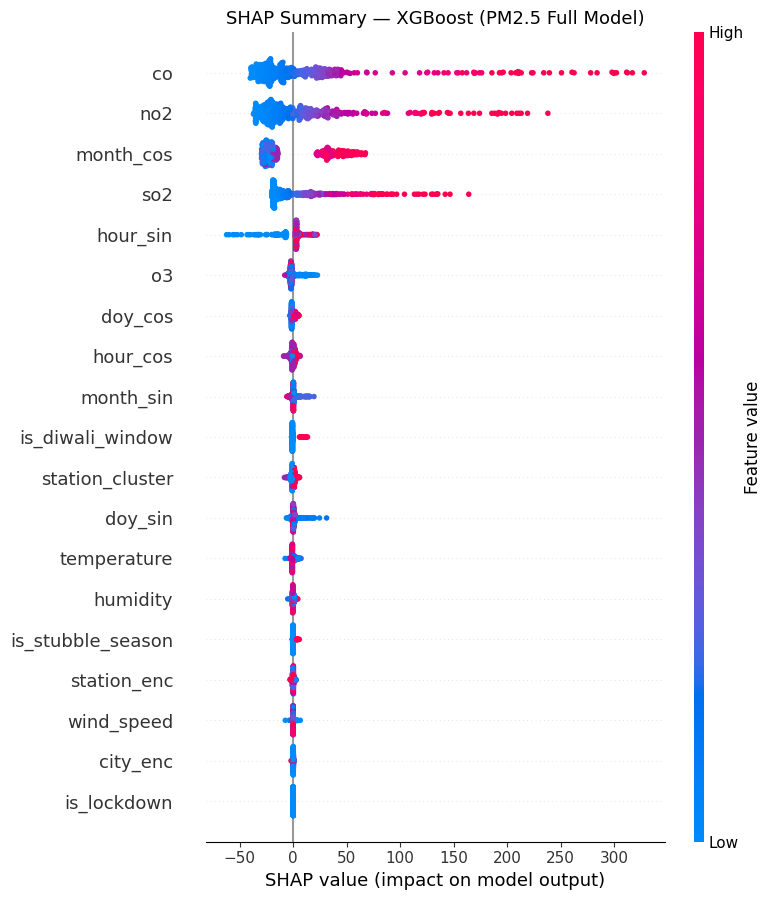

[17:35:07] Computing mean SHAP importance...

=== Mean SHAP Importance (XGBoost PM2.5) ===
          feature  mean_shap
               co      40.37
              no2      31.25
        month_cos      29.75
              so2      22.37
         hour_sin       7.11
               o3       3.27
          doy_cos       1.83
         hour_cos       1.65
        month_sin       1.57
 is_diwali_window       1.50
  station_cluster       1.43
          doy_sin       1.42
      temperature       1.37
         humidity       0.73
is_stubble_season       0.45
      station_enc       0.44
       wind_speed       0.33
         city_enc       0.13
      is_lockdown       0.00


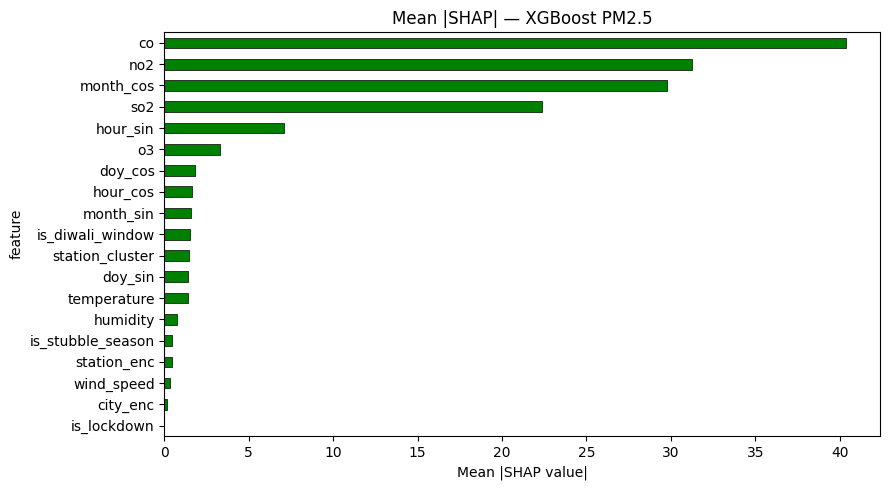

[17:35:08] Computing group contributions...

=== SHAP GROUP CONTRIBUTION (XGBoost PM2.5) ===
Meteorology                    : 1.65%
Pollutants                     : 66.18%
Temporal / Human Activity      : 30.81%
Spatial                        : 1.36%


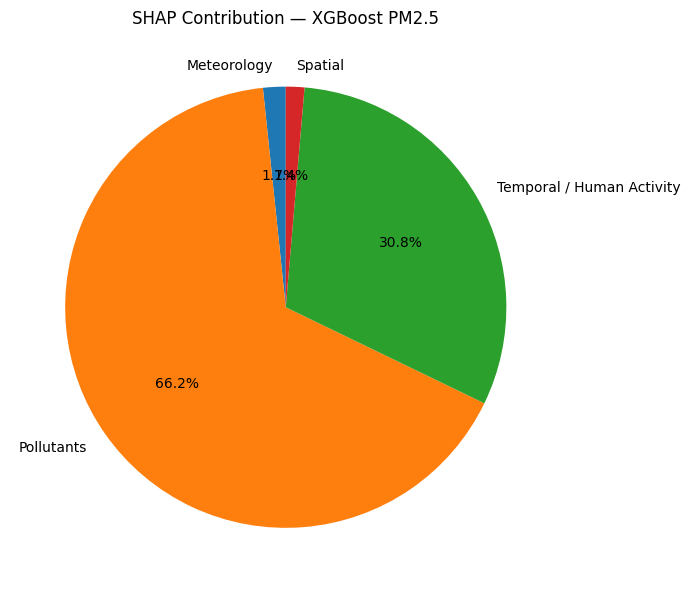


✓ SHAP analysis complete (XGBoost PM2.5)


In [ ]:
# ============================================================
# SHAP — FULL XGBOOST MODEL (PM2.5)
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time


def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")


# ─────────────────────────────────────────────────────────────
# Build SHAP explainer
# ─────────────────────────────────────────────────────────────
log("Building SHAP explainer...")

explainer_xgb = shap.Explainer(
    xgb_PM25,          # trained XGBoost model
    X_train_PM25       # background data
)


# ─────────────────────────────────────────────────────────────
# Sample test data (for speed)
# ─────────────────────────────────────────────────────────────
log("Sampling test data...")

sample_size = min(500, len(X_test_PM25))

sample_idx = np.random.choice(
    len(X_test_PM25),
    size=sample_size,
    replace=False
)

X_shap = X_test_PM25.iloc[sample_idx]


# ─────────────────────────────────────────────────────────────
# Compute SHAP values
# ─────────────────────────────────────────────────────────────
log("Computing SHAP values...")

shap_values = explainer_xgb(X_shap)


# ─────────────────────────────────────────────────────────────
# SHAP Summary Plot (global explanation)
# ─────────────────────────────────────────────────────────────
log("Creating SHAP summary plot...")

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values.values,
    X_shap,
    show=False
)

plt.title(
    "SHAP Summary — XGBoost (PM2.5 Full Model)",
    fontsize=13
)

plt.tight_layout()
plt.savefig(
    "shap_summary_xgb_pm25.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# ─────────────────────────────────────────────────────────────
# Mean SHAP Importance
# ─────────────────────────────────────────────────────────────
log("Computing mean SHAP importance...")

mean_shap = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_shap", ascending=False)

print("\n=== Mean SHAP Importance (XGBoost PM2.5) ===")
print(mean_shap.to_string(index=False))


# Bar plot
fig, ax = plt.subplots(figsize=(9, 5))

mean_shap.plot(
    kind="barh",
    x="feature",
    y="mean_shap",
    ax=ax,
    color="green",
    edgecolor="black",
    linewidth=0.5
)

ax.invert_yaxis()
ax.set_title("Mean |SHAP| — XGBoost PM2.5")
ax.set_xlabel("Mean |SHAP value|")
ax.legend().remove()

plt.tight_layout()
plt.savefig(
    "shap_bar_xgb_pm25.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# ─────────────────────────────────────────────────────────────
# GROUPED CONTRIBUTION (YOUR RESEARCH QUESTION)
# ─────────────────────────────────────────────────────────────
log("Computing group contributions...")

groups = {
    "Meteorology": [
        "temperature",
        "humidity",
        "wind_speed"
    ],

    "Pollutants": [
        "no2",
        "so2",
        "co",
        "o3"
    ],

    "Temporal / Human Activity": [
        "hour_sin", "hour_cos",
        "doy_sin", "doy_cos",
        "month_sin", "month_cos",
        "is_lockdown",
        "is_diwali_window",
        "is_stubble_season"
    ],

    "Spatial": [
        "city_enc",
        "station_enc",
        "station_cluster"
    ]
}


group_importance = {}

for group, feats in groups.items():

    idx = [
        FEATURES_PM25.index(f)
        for f in feats
        if f in FEATURES_PM25
    ]

    group_importance[group] = np.abs(
        shap_values.values[:, idx]
    ).sum(axis=1).mean()


# normalize
total = sum(group_importance.values())

group_percent = {
    k: (v / total) * 100
    for k, v in group_importance.items()
}


# ─────────────────────────────────────────────────────────────
# PRINT RESULTS
# ─────────────────────────────────────────────────────────────
print("\n=== SHAP GROUP CONTRIBUTION (XGBoost PM2.5) ===")

for k, v in group_percent.items():
    print(f"{k:<30} : {v:.2f}%")


# ─────────────────────────────────────────────────────────────
# PIE CHART
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 7))

plt.pie(
    group_percent.values(),
    labels=group_percent.keys(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("SHAP Contribution — XGBoost PM2.5")
plt.tight_layout()
plt.savefig("shap_pie_xgb_pm25.png", dpi=150)
plt.show()


print("\n✓ SHAP analysis complete (XGBoost PM2.5)")
